# NSW Transport Operations Analytics & Digital Insights Project

This notebook builds an end-to-end transport operations analytics workflow using NSW public transport, station flow, GTFS timetable, weather and public holiday data.

The project covers:

1. Data loading and cleaning  
2. Weather and calendar feature engineering  
3. Station and route processing using GTFS data  
4. SQL data modelling with DuckDB  
5. Demand and station flow analysis  
6. Bottleneck and operational pressure analysis  
7. Machine learning demand forecasting  
8. Data quality and risk assessment  
9. Exporting datasets for Tableau dashboard

In [2]:
# ==============================
# 0. Project Setup
# ==============================

import os
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 50)
pd.set_option("display.float_format", "{:,.2f}".format)

# Project paths
PROJECT_ROOT = Path("..")

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FINAL_DIR = PROJECT_ROOT / "data" / "final"

OUTPUT_DIR = PROJECT_ROOT / "outputs"
CHART_DIR = OUTPUT_DIR / "charts"
SQL_EXPORT_DIR = OUTPUT_DIR / "sql_exports"
MODEL_RESULT_DIR = OUTPUT_DIR / "model_results"

DASHBOARD_DIR = PROJECT_ROOT / "dashboard"
DASHBOARD_DATA_DIR = DASHBOARD_DIR / "dashboard_data"

REPORT_DIR = PROJECT_ROOT / "reports"
SQL_DIR = PROJECT_ROOT / "sql"

# Create folders if they do not exist
for folder in [
    PROCESSED_DIR,
    FINAL_DIR,
    CHART_DIR,
    SQL_EXPORT_DIR,
    MODEL_RESULT_DIR,
    DASHBOARD_DATA_DIR,
    REPORT_DIR,
    SQL_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project folders are ready.")
print("Raw data folder:", RAW_DIR.resolve())

Project folders are ready.
Raw data folder: /Users/raina/Desktop/Github/nsw-transport-operations-analytics/data/raw


In [3]:
# ==============================
# 1. Check Raw Data Files
# ==============================

raw_files = list(RAW_DIR.glob("*"))

print("Files in data/raw:")
for file in raw_files:
    print("-", file.name)

Files in data/raw:
- .DS_Store
- sydney_airport_daily_rainfall.csv
- NSW-2-Opal-trips-all-modes.csv
- full_greater_sydney_gtfs_static_0
- NSW-train-station-entries-and-exits.csv
- sydney_airport_daily_min_temp.csv
- nsw_public_holidays_2019_2023.csv
- sydney_airport_daily_max_temp.csv


In [4]:
# ==============================
# 2. Define Data File Paths
# ==============================

opal_path = RAW_DIR / "NSW-2-Opal-trips-all-modes.csv"
station_flow_path = RAW_DIR / "NSW-train-station-entries-and-exits.csv"

rainfall_path = RAW_DIR / "sydney_airport_daily_rainfall.csv"
max_temp_path = RAW_DIR / "sydney_airport_daily_max_temp.csv"
min_temp_path = RAW_DIR / "sydney_airport_daily_min_temp.csv"

holiday_path = RAW_DIR / "nsw_public_holidays_2019_2023.csv"

gtfs_dir = RAW_DIR / "full_greater_sydney_gtfs_static_0"
stops_path = gtfs_dir / "stops.txt"
routes_path = gtfs_dir / "routes.txt"

required_files = {
    "Opal trips": opal_path,
    "Station flow": station_flow_path,
    "Rainfall": rainfall_path,
    "Max temperature": max_temp_path,
    "Min temperature": min_temp_path,
    "Public holidays": holiday_path,
    "GTFS stops": stops_path,
    "GTFS routes": routes_path,
}

for name, path in required_files.items():
    if path.exists():
        print(f"✅ {name}: {path.name}")
    else:
        print(f"❌ Missing {name}: {path}")

✅ Opal trips: NSW-2-Opal-trips-all-modes.csv
✅ Station flow: NSW-train-station-entries-and-exits.csv
✅ Rainfall: sydney_airport_daily_rainfall.csv
✅ Max temperature: sydney_airport_daily_max_temp.csv
✅ Min temperature: sydney_airport_daily_min_temp.csv
✅ Public holidays: nsw_public_holidays_2019_2023.csv
✅ GTFS stops: stops.txt
✅ GTFS routes: routes.txt


## 1. Data Loading

This section loads all raw datasets used in the project, including Opal trip demand, train station entries and exits, GTFS station and route information, weather observations and NSW public holidays.

In [5]:
# ==============================
# 3. Load Raw Datasets
# ==============================

opal_raw = pd.read_csv(opal_path)
station_flow_raw = pd.read_csv(station_flow_path)

rainfall_raw = pd.read_csv(rainfall_path)
max_temp_raw = pd.read_csv(max_temp_path)
min_temp_raw = pd.read_csv(min_temp_path)

holidays_raw = pd.read_csv(holiday_path)

stops_raw = pd.read_csv(stops_path)
routes_raw = pd.read_csv(routes_path)

print("Raw datasets loaded successfully.")

datasets = {
    "opal_raw": opal_raw,
    "station_flow_raw": station_flow_raw,
    "rainfall_raw": rainfall_raw,
    "max_temp_raw": max_temp_raw,
    "min_temp_raw": min_temp_raw,
    "holidays_raw": holidays_raw,
    "stops_raw": stops_raw,
    "routes_raw": routes_raw,
}

for name, df in datasets.items():
    print(f"{name}: {df.shape[0]:,} rows, {df.shape[1]:,} columns")

Raw datasets loaded successfully.
opal_raw: 6,280 rows, 4 columns
station_flow_raw: 2,329 rows, 12 columns
rainfall_raw: 35,574 rows, 8 columns
max_temp_raw: 31,921 rows, 8 columns
min_temp_raw: 31,922 rows, 8 columns
holidays_raw: 61 rows, 2 columns
stops_raw: 170,501 rows, 10 columns
routes_raw: 10,201 rows, 9 columns


/var/folders/56/5hhy_nc96sd14853bqkqxlg00000gn/T/ipykernel_52823/1645132969.py:14: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  stops_raw = pd.read_csv(stops_path)


In [6]:
# ==============================
# 4. Inspect Column Names
# ==============================

for name, df in datasets.items():
    print("=" * 80)
    print(name)
    print(df.columns.tolist())
    print(df.head(3))

opal_raw
['Year_Month', 'Card_type', 'Travel_Mode', 'Trip']
  Year_Month    Card_type Travel_Mode          Trip
0   Jul-2016        Adult         Bus 13,146,432.00
1   Jul-2016  Child/Youth         Bus  1,079,640.00
2   Jul-2016   Concession         Bus  1,845,322.00
station_flow_raw
['YEAR', 'STATION', 'Entries 06:00 to 10:00', 'Exits 06:00 to 10:00', 'Entries 10:00 to 15:00', 'Exits 10:00 to 15:00', 'Entries 15:00 to 19:00', 'Exits 15:00 to 19:00', 'Entries 19:00  to 06:00', 'Exits 19:00  to 06:00', 'Entries 24 hours', 'Exits 24 hours']
   YEAR              STATION Entries 06:00 to 10:00 Exits 06:00 to 10:00  \
0  2016    Adamstown Station                      -                    -   
1  2016  Albion Park Station                      -                    -   
2  2016      Allawah Station                   1650                  140   

  Entries 10:00 to 15:00 Exits 10:00 to 15:00 Entries 15:00 to 19:00  \
0                      -                    -                      -   
1     

## 2. Data Cleaning

This section cleans the raw transport demand, station flow, weather, public holiday and GTFS datasets. The goal is to standardise column names, convert date fields, handle missing values and prepare the data for SQL modelling and dashboard analysis.

In [7]:
# ==============================
# 5. Clean Opal Monthly Trips Data
# ==============================

opal = opal_raw.copy()

# Standardise column names
opal.columns = (
    opal.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

# Convert Year_Month into datetime
opal["year_month"] = pd.to_datetime(opal["year_month"], format="%b-%Y")

# Extract year and month
opal["year"] = opal["year_month"].dt.year
opal["month"] = opal["year_month"].dt.month
opal["month_name"] = opal["year_month"].dt.month_name()

# Clean trip count
opal["trip"] = (
    opal["trip"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype(float)
)

# Rename columns
opal = opal.rename(columns={
    "card_type": "card_type",
    "travel_mode": "transport_mode",
    "trip": "trip_count"
})

# Filter project period: 2020-2025
opal = opal[
    (opal["year"] >= 2020) &
    (opal["year"] <= 2025)
].copy()

# Reorder columns
opal = opal[
    [
        "year_month",
        "year",
        "month",
        "month_name",
        "card_type",
        "transport_mode",
        "trip_count"
    ]
]

print("Cleaned Opal trips data:")
print(opal.shape)
display(opal.head())
display(opal.tail())

Cleaned Opal trips data:
(4261, 7)


,year_month,year,month,month_name,card_type,transport_mode,trip_count
2019,2020-01-01,2020,1,January,Adult,Bus,"12,404,965.00"
2020,2020-01-01,2020,1,January,Adult Single Bus Trip 1,Bus,"49,458.00"
2021,2020-01-01,2020,1,January,Adult Single Bus Trip 2,Bus,"25,989.00"
2022,2020-01-01,2020,1,January,Adult Single Bus Trip 3,Bus,"7,329.00"
2023,2020-01-01,2020,1,January,CTP,Bus,"2,628,423.00"


,year_month,year,month,month_name,card_type,transport_mode,trip_count
6275,2024-09-01,2024,9,September,UNKNOWN,bus,78.00
6276,2024-09-01,2024,9,September,UNKNOWN,ferry,5.00
6277,2024-09-01,2024,9,September,UNKNOWN,light rail,1.00
6278,2024-09-01,2024,9,September,UNKNOWN,metro,3.52
6279,2024-09-01,2024,9,September,UNKNOWN,train,112.79


我们把 Jul-2016 这种字符串变成真正的日期格式，然后筛选 2020–2025。因为你项目的主分析时间范围就是这几年

In [8]:
# ==============================
# 6. Basic Quality Check: Opal Data
# ==============================

print("Missing values:")
display(opal.isna().sum())

print("\nDate range:")
print(opal["year_month"].min(), "to", opal["year_month"].max())

print("\nTransport modes:")
display(opal["transport_mode"].value_counts())

print("\nCard types:")
display(opal["card_type"].value_counts())

print("\nTotal trips by year:")
display(
    opal.groupby("year", as_index=False)["trip_count"]
    .sum()
    .sort_values("year")
)

Missing values:


year_month        0
year              0
month             0
month_name        0
card_type         0
transport_mode    0
trip_count        0
dtype: int64


Date range:
2020-01-01 00:00:00 to 2025-08-01 00:00:00

Transport modes:


transport_mode
Bus            773
Train          574
Light Rail     550
Ferry          545
Metro          531
train          260
light rail     254
metro          253
ferry          248
bus            239
unallocated     34
Name: count, dtype: int64


Card types:


card_type
CTP                              348
Adult                            347
Child/Youth                      345
Employee                         345
Concession                       342
Free Travel                      341
Senior/Pensioner                 341
School Student                   340
Day Pass without SAF             339
Day Pass Child/Youth w/o SAF     221
Sgl Trip Rail Adult              139
Sgl Trip Rail Child/Youth        138
UNKNOWN                           89
Sgl Trip Ferry Adult              68
Sgl Trip LR Child/Youth           68
Sgl Trip LR Adult                 68
Sgl Trip Ferry Child/Youth        68
On Demand                         67
Adult Single Bus Trip 2           48
Adult Single Bus Trip 1           48
Adult Single Bus Trip 3           48
Child/Youth Single Bus Trip 1     43
Child/Youth Single Bus Trip 2     36
Child/Youth Single Bus Trip 3     24
Name: count, dtype: int64


Total trips by year:


,year,trip_count
0,2020,"415,476,701.00"
1,2021,"329,991,592.00"
2,2022,"437,435,557.00"
3,2023,"598,957,085.00"
4,2024,"650,705,180.82"
5,2025,"436,431,948.14"


In [9]:
# ==============================
# 7. Clean Train Station Entries and Exits Data
# ==============================

station_flow = station_flow_raw.copy()

# Standardise column names manually because the original names are long
station_flow = station_flow.rename(columns={
    "YEAR": "year",
    "STATION": "station_name",
    "Entries 06:00 to 10:00": "morning_entries",
    "Exits 06:00 to 10:00": "morning_exits",
    "Entries 10:00 to 15:00": "midday_entries",
    "Exits 10:00 to 15:00": "midday_exits",
    "Entries 15:00 to 19:00": "evening_entries",
    "Exits 15:00 to 19:00": "evening_exits",
    "Entries 19:00  to 06:00": "night_entries",
    "Exits 19:00  to 06:00": "night_exits",
    "Entries 24 hours": "total_entries",
    "Exits 24 hours": "total_exits"
})

# Convert year from string to numeric
station_flow["year"] = pd.to_numeric(station_flow["year"], errors="coerce")

# Drop rows where year is missing or invalid
station_flow = station_flow.dropna(subset=["year"]).copy()
station_flow["year"] = station_flow["year"].astype(int)

# Replace '-' with 0 and convert numeric columns
numeric_cols = [
    "morning_entries", "morning_exits",
    "midday_entries", "midday_exits",
    "evening_entries", "evening_exits",
    "night_entries", "night_exits",
    "total_entries", "total_exits"
]

for col in numeric_cols:
    station_flow[col] = (
        station_flow[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("-", "0", regex=False)
        .str.strip()
    )
    station_flow[col] = pd.to_numeric(station_flow[col], errors="coerce").fillna(0)

# Clean station name
station_flow["station_name"] = (
    station_flow["station_name"]
    .astype(str)
    .str.strip()
)

# Filter project period
station_flow = station_flow[
    (station_flow["year"] >= 2020) &
    (station_flow["year"] <= 2025)
].copy()

# Create total flow and operational indicators
station_flow["total_flow"] = station_flow["total_entries"] + station_flow["total_exits"]

station_flow["morning_total_flow"] = (
    station_flow["morning_entries"] + station_flow["morning_exits"]
)

station_flow["midday_total_flow"] = (
    station_flow["midday_entries"] + station_flow["midday_exits"]
)

station_flow["evening_total_flow"] = (
    station_flow["evening_entries"] + station_flow["evening_exits"]
)

station_flow["night_total_flow"] = (
    station_flow["night_entries"] + station_flow["night_exits"]
)

# Entry-exit imbalance: positive means more entries than exits
station_flow["entry_exit_imbalance"] = (
    station_flow["total_entries"] - station_flow["total_exits"]
)

# Peak flow = morning + evening
station_flow["peak_total_flow"] = (
    station_flow["morning_total_flow"] + station_flow["evening_total_flow"]
)

# Bottleneck score: proportion of total flow concentrated in peak windows
station_flow["bottleneck_score"] = np.where(
    station_flow["total_flow"] > 0,
    station_flow["peak_total_flow"] / station_flow["total_flow"],
    0
)

# Create station_id from station name
station_flow["station_id"] = (
    station_flow["station_name"]
    .str.lower()
    .str.replace(" station", "", regex=False)
    .str.replace(r"[^a-z0-9]+", "_", regex=True)
    .str.strip("_")
)

# Reorder columns
station_flow = station_flow[
    [
        "year",
        "station_id",
        "station_name",
        "morning_entries",
        "morning_exits",
        "midday_entries",
        "midday_exits",
        "evening_entries",
        "evening_exits",
        "night_entries",
        "night_exits",
        "total_entries",
        "total_exits",
        "total_flow",
        "morning_total_flow",
        "midday_total_flow",
        "evening_total_flow",
        "night_total_flow",
        "peak_total_flow",
        "entry_exit_imbalance",
        "bottleneck_score"
    ]
]

print("Cleaned station flow data:")
print(station_flow.shape)
display(station_flow.head())

Cleaned station flow data:
(521, 21)


,year,station_id,station_name,morning_entries,morning_exits,midday_entries,midday_exits,evening_entries,evening_exits,night_entries,night_exits,total_entries,total_exits,total_flow,morning_total_flow,midday_total_flow,evening_total_flow,night_total_flow,peak_total_flow,entry_exit_imbalance,bottleneck_score
1808,2022,adamstown,Adamstown Station,0,0,0,0,0,0,0,0,80,70,150,0,0,0,0,0,10,0.00
1809,2022,albion_park,Albion Park Station,0,0,0,0,0,0,0,0,190,160,350,0,0,0,0,0,30,0.00
1810,2022,allawah,Allawah Station,920,160,390,230,310,750,230,530,1850,1670,3520,1080,620,1060,760,2140,180,0.61
1811,2022,arncliffe,Arncliffe Station,860,140,280,200,290,700,120,300,1550,1340,2890,1000,480,990,420,1990,210,0.69
1812,2022,artarmon,Artarmon Station,1600,500,650,610,960,1490,250,750,3460,3350,6810,2100,1260,2450,1000,4550,110,0.67


In [10]:
# ==============================
# 8. Station Flow Quality Check and Preview
# ==============================

print("Missing values:")
display(station_flow.isna().sum())

print("\nYear range:")
print(station_flow["year"].min(), "to", station_flow["year"].max())

print("\nNumber of unique stations:")
print(station_flow["station_name"].nunique())

print("\nTop 10 stations by total flow:")
display(
    station_flow.groupby("station_name", as_index=False)["total_flow"]
    .sum()
    .sort_values("total_flow", ascending=False)
    .head(10)
)

print("\nTop 10 stations by bottleneck score:")
display(
    station_flow[station_flow["total_flow"] > 0]
    .groupby("station_name", as_index=False)
    .agg(
        avg_bottleneck_score=("bottleneck_score", "mean"),
        total_flow=("total_flow", "sum")
    )
    .sort_values("avg_bottleneck_score", ascending=False)
    .head(10)
)

Missing values:


year                    0
station_id              0
station_name            0
morning_entries         0
morning_exits           0
midday_entries          0
midday_exits            0
evening_entries         0
evening_exits           0
night_entries           0
night_exits             0
total_entries           0
total_exits             0
total_flow              0
morning_total_flow      0
midday_total_flow       0
evening_total_flow      0
night_total_flow        0
peak_total_flow         0
entry_exit_imbalance    0
bottleneck_score        0
dtype: int64


Year range:
2022 to 2023

Number of unique stations:
263

Top 10 stations by total flow:


,station_name,total_flow
224,Town Hall Station,289960
48,Central Station,260300
259,Wynyard Station,243020
175,Parramatta Station,132130
53,Circular Quay Station,109210
49,Chatswood Station,88130
187,Redfern Station,81610
210,Strathfield Station,77540
166,North Sydney Station,77230
29,Bondi Junction Station,74050



Top 10 stations by bottleneck score:


,station_name,avg_bottleneck_score,total_flow
20,Berowra Station,0.78,3830
134,Macquarie Park Station,0.78,13480
219,Tempe Station,0.78,4140
166,North Sydney Station,0.76,77230
239,Warrawee Station,0.76,2830
74,Emu Plains Station,0.75,3240
215,Tallawong Station,0.75,15430
6,Asquith Station,0.74,4340
139,Martin Place Station,0.74,63790
185,Pymble Station,0.74,7220


# 清洗 Weather 数据

接下来我们合并 rainfall、max temp、min temp。

In [11]:
# ==============================
# 9. Clean and Merge Weather Data
# ==============================

def create_date_from_bom(df):
    """Create a date column from BOM Year, Month, Day columns."""
    df = df.copy()
    df["date"] = pd.to_datetime(
        df[["Year", "Month", "Day"]],
        errors="coerce"
    )
    return df


# Rainfall
rainfall = create_date_from_bom(rainfall_raw)
rainfall = rainfall.rename(columns={
    "Rainfall amount (millimetres)": "rainfall_mm"
})
rainfall = rainfall[["date", "rainfall_mm", "Quality"]].rename(columns={
    "Quality": "rainfall_quality"
})

# Max temperature
max_temp = create_date_from_bom(max_temp_raw)
max_temp = max_temp.rename(columns={
    "Maximum temperature (Degree C)": "max_temp"
})
max_temp = max_temp[["date", "max_temp", "Quality"]].rename(columns={
    "Quality": "max_temp_quality"
})

# Min temperature
min_temp = create_date_from_bom(min_temp_raw)
min_temp = min_temp.rename(columns={
    "Minimum temperature (Degree C)": "min_temp"
})
min_temp = min_temp[["date", "min_temp", "Quality"]].rename(columns={
    "Quality": "min_temp_quality"
})

# Merge weather tables
weather = (
    rainfall
    .merge(max_temp, on="date", how="outer")
    .merge(min_temp, on="date", how="outer")
)

# Filter project period
weather = weather[
    (weather["date"] >= "2020-01-01") &
    (weather["date"] <= "2025-12-31")
].copy()

# Sort by date
weather = weather.sort_values("date").reset_index(drop=True)

# Fill rainfall missing values with 0 only when temperature exists
# This is a reasonable assumption for missing rainfall records in some daily observation datasets.
weather["rainfall_mm"] = weather["rainfall_mm"].fillna(0)

# Weather features
weather["is_rainy"] = weather["rainfall_mm"] > 0

def classify_weather(row):
    if row["rainfall_mm"] >= 10:
        return "Heavy Rain"
    elif row["rainfall_mm"] > 0:
        return "Rainy"
    elif pd.notna(row["max_temp"]) and row["max_temp"] >= 30:
        return "Hot"
    elif pd.notna(row["max_temp"]) and row["max_temp"] <= 15:
        return "Cool"
    else:
        return "Clear / Mild"

weather["weather_category"] = weather.apply(classify_weather, axis=1)

# Keep clean columns
weather = weather[
    [
        "date",
        "rainfall_mm",
        "max_temp",
        "min_temp",
        "is_rainy",
        "weather_category",
        "rainfall_quality",
        "max_temp_quality",
        "min_temp_quality"
    ]
]

print("Cleaned weather data:")
print(weather.shape)
display(weather.head())
display(weather.tail())

Cleaned weather data:
(2192, 9)


,date,rainfall_mm,max_temp,min_temp,is_rainy,weather_category,rainfall_quality,max_temp_quality,min_temp_quality
0,2020-01-01,0.00,26.20,18.50,False,Clear / Mild,Y,N,N
1,2020-01-02,0.00,26.60,19.10,False,Clear / Mild,Y,N,N
2,2020-01-03,0.00,30.90,20.90,False,Hot,Y,N,N
3,2020-01-04,0.00,43.30,22.10,False,Hot,Y,N,N
4,2020-01-05,0.00,24.40,20.80,False,Clear / Mild,Y,N,N


,date,rainfall_mm,max_temp,min_temp,is_rainy,weather_category,rainfall_quality,max_temp_quality,min_temp_quality
2187,2025-12-27,0.00,21.50,14.60,False,Clear / Mild,N,N,N
2188,2025-12-28,0.40,22.70,14.90,True,Rainy,N,N,N
2189,2025-12-29,0.00,23.40,15.90,False,Clear / Mild,N,N,N
2190,2025-12-30,0.00,24.10,15.10,False,Clear / Mild,N,N,N
2191,2025-12-31,0.00,24.20,17.10,False,Clear / Mild,N,N,N


In [12]:
# ==============================
# 10. Weather Quality Check
# ==============================

print("Date range:")
print(weather["date"].min(), "to", weather["date"].max())

print("\nMissing values:")
display(weather.isna().sum())

print("\nWeather category distribution:")
display(weather["weather_category"].value_counts())

print("\nRainy day distribution:")
display(weather["is_rainy"].value_counts())

print("\nWeather summary:")
display(
    weather[["rainfall_mm", "max_temp", "min_temp"]].describe()
)

Date range:
2020-01-01 00:00:00 to 2025-12-31 00:00:00

Missing values:


date                 0
rainfall_mm          0
max_temp             5
min_temp            16
is_rainy             0
weather_category     0
rainfall_quality    23
max_temp_quality     5
min_temp_quality    19
dtype: int64


Weather category distribution:


weather_category
Clear / Mild    1142
Rainy            646
Heavy Rain       223
Hot              168
Cool              13
Name: count, dtype: int64


Rainy day distribution:


is_rainy
False    1323
True      869
Name: count, dtype: int64


Weather summary:


,rainfall_mm,max_temp,min_temp
count,"2,192.00","2,187.00","2,176.00"
mean,3.85,23.38,14.73
std,12.02,4.98,4.41
min,0.00,11.40,4.60
25%,0.00,19.50,11.00
50%,0.00,23.10,15.10
75%,1.80,26.60,18.40
max,161.00,43.70,24.20


In [13]:
# ==============================
# 11. Export Initial Cleaned Datasets
# ==============================

opal.to_csv(PROCESSED_DIR / "clean_opal_trips.csv", index=False)
station_flow.to_csv(PROCESSED_DIR / "clean_station_flow.csv", index=False)
weather.to_csv(PROCESSED_DIR / "clean_weather.csv", index=False)

print("Cleaned datasets exported to data/processed:")
print("- clean_opal_trips.csv")
print("- clean_station_flow.csv")
print("- clean_weather.csv")

Cleaned datasets exported to data/processed:
- clean_opal_trips.csv
- clean_station_flow.csv
- clean_weather.csv


## 3. Calendar and Public Holiday Feature Engineering

This section cleans NSW public holiday data and creates a complete date dimension table for 2020–2025. The date dimension will support weekday/weekend analysis, public holiday indicators, seasonal patterns and forecasting features.

In [14]:
# ==============================
# 12. Clean NSW Public Holidays
# ==============================

holidays = holidays_raw.copy()

# Standardise column names
holidays.columns = (
    holidays.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

# Rename columns
holidays = holidays.rename(columns={
    "day": "date",
    "significance": "holiday_name"
})

# Convert date
holidays["date"] = pd.to_datetime(
    holidays["date"],
    dayfirst=True,
    errors="coerce"
)

# Keep useful columns
holidays = holidays[["date", "holiday_name"]].dropna(subset=["date"])

# Filter 2020-2023 from downloaded CSV
holidays = holidays[
    (holidays["date"] >= "2020-01-01") &
    (holidays["date"] <= "2023-12-31")
].copy()

print("Downloaded public holidays:")
print(holidays.shape)
display(holidays.head())
display(holidays.tail())

Downloaded public holidays:
(50, 2)


,date,holiday_name
11,2020-01-01,New Year's Day
12,2020-01-27,Australia Day
13,2020-04-10,Good Friday
14,2020-04-11,Easter Saturday
15,2020-04-12,Easter Sunday


,date,holiday_name
56,2023-04-25,Anzac Day
57,2023-06-12,Queen's Birthday
58,2023-10-02,Labour Day
59,2023-12-25,Christmas Day
60,2023-12-26,Boxing Day


In [15]:
# ==============================
# 13. Add Manual NSW Public Holidays for 2024-2025
# ==============================

manual_holidays = pd.DataFrame({
    "date": [
        # 2024
        "2024-01-01",
        "2024-01-26",
        "2024-03-29",
        "2024-03-30",
        "2024-03-31",
        "2024-04-01",
        "2024-04-25",
        "2024-06-10",
        "2024-10-07",
        "2024-12-25",
        "2024-12-26",

        # 2025
        "2025-01-01",
        "2025-01-27",
        "2025-04-18",
        "2025-04-19",
        "2025-04-20",
        "2025-04-21",
        "2025-04-25",
        "2025-06-09",
        "2025-10-06",
        "2025-12-25",
        "2025-12-26",
    ],
    "holiday_name": [
        # 2024
        "New Year's Day",
        "Australia Day",
        "Good Friday",
        "Easter Saturday",
        "Easter Sunday",
        "Easter Monday",
        "Anzac Day",
        "King's Birthday",
        "Labour Day",
        "Christmas Day",
        "Boxing Day",

        # 2025
        "New Year's Day",
        "Australia Day Holiday",
        "Good Friday",
        "Easter Saturday",
        "Easter Sunday",
        "Easter Monday",
        "Anzac Day",
        "King's Birthday",
        "Labour Day",
        "Christmas Day",
        "Boxing Day",
    ]
})

manual_holidays["date"] = pd.to_datetime(manual_holidays["date"])

# Combine downloaded and manual holidays
all_holidays = pd.concat([holidays, manual_holidays], ignore_index=True)

# Remove duplicates just in case
all_holidays = all_holidays.drop_duplicates(subset=["date", "holiday_name"])

# Create is_holiday flag
all_holidays["is_holiday"] = True

print("Combined public holidays:")
print(all_holidays.shape)
display(all_holidays.head())
display(all_holidays.tail())

Combined public holidays:
(72, 3)


,date,holiday_name,is_holiday
0,2020-01-01,New Year's Day,True
1,2020-01-27,Australia Day,True
2,2020-04-10,Good Friday,True
3,2020-04-11,Easter Saturday,True
4,2020-04-12,Easter Sunday,True


,date,holiday_name,is_holiday
67,2025-04-25,Anzac Day,True
68,2025-06-09,King's Birthday,True
69,2025-10-06,Labour Day,True
70,2025-12-25,Christmas Day,True
71,2025-12-26,Boxing Day,True


In [16]:
# ==============================
# 14. Create Date Dimension Table
# ==============================

date_range = pd.date_range(
    start="2020-01-01",
    end="2025-12-31",
    freq="D"
)

dim_date = pd.DataFrame({"date": date_range})

dim_date["year"] = dim_date["date"].dt.year
dim_date["quarter"] = dim_date["date"].dt.quarter
dim_date["month"] = dim_date["date"].dt.month
dim_date["month_name"] = dim_date["date"].dt.month_name()
dim_date["day"] = dim_date["date"].dt.day
dim_date["weekday"] = dim_date["date"].dt.weekday
dim_date["weekday_name"] = dim_date["date"].dt.day_name()
dim_date["is_weekend"] = dim_date["weekday"].isin([5, 6])

# Season mapping for Australia
def assign_season(month):
    if month in [12, 1, 2]:
        return "Summer"
    elif month in [3, 4, 5]:
        return "Autumn"
    elif month in [6, 7, 8]:
        return "Winter"
    else:
        return "Spring"

dim_date["season"] = dim_date["month"].apply(assign_season)

# Merge holiday information
dim_date = dim_date.merge(
    all_holidays[["date", "holiday_name", "is_holiday"]],
    on="date",
    how="left"
)

dim_date["is_holiday"] = dim_date["is_holiday"].fillna(False)
dim_date["holiday_name"] = dim_date["holiday_name"].fillna("Non-Holiday")

# Add year_month for monthly analysis
dim_date["year_month"] = dim_date["date"].dt.to_period("M").astype(str)

# Reorder columns
dim_date = dim_date[
    [
        "date",
        "year",
        "quarter",
        "month",
        "month_name",
        "day",
        "weekday",
        "weekday_name",
        "is_weekend",
        "is_holiday",
        "holiday_name",
        "season",
        "year_month"
    ]
]

print("Date dimension table:")
print(dim_date.shape)
display(dim_date.head())
display(dim_date.tail())

Date dimension table:
(2192, 13)


/var/folders/56/5hhy_nc96sd14853bqkqxlg00000gn/T/ipykernel_52823/2984620058.py:42: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dim_date["is_holiday"] = dim_date["is_holiday"].fillna(False)


,date,year,quarter,month,month_name,day,weekday,weekday_name,is_weekend,is_holiday,holiday_name,season,year_month
0,2020-01-01,2020,1,1,January,1,2,Wednesday,False,True,New Year's Day,Summer,2020-01
1,2020-01-02,2020,1,1,January,2,3,Thursday,False,False,Non-Holiday,Summer,2020-01
2,2020-01-03,2020,1,1,January,3,4,Friday,False,False,Non-Holiday,Summer,2020-01
3,2020-01-04,2020,1,1,January,4,5,Saturday,True,False,Non-Holiday,Summer,2020-01
4,2020-01-05,2020,1,1,January,5,6,Sunday,True,False,Non-Holiday,Summer,2020-01


,date,year,quarter,month,month_name,day,weekday,weekday_name,is_weekend,is_holiday,holiday_name,season,year_month
2187,2025-12-27,2025,4,12,December,27,5,Saturday,True,False,Non-Holiday,Summer,2025-12
2188,2025-12-28,2025,4,12,December,28,6,Sunday,True,False,Non-Holiday,Summer,2025-12
2189,2025-12-29,2025,4,12,December,29,0,Monday,False,False,Non-Holiday,Summer,2025-12
2190,2025-12-30,2025,4,12,December,30,1,Tuesday,False,False,Non-Holiday,Summer,2025-12
2191,2025-12-31,2025,4,12,December,31,2,Wednesday,False,False,Non-Holiday,Summer,2025-12


In [17]:
# ==============================
# 15. Date Dimension Quality Check
# ==============================

print("Date range:")
print(dim_date["date"].min(), "to", dim_date["date"].max())

print("\nNumber of dates:")
print(len(dim_date))

print("\nHoliday count by year:")
display(
    dim_date[dim_date["is_holiday"]]
    .groupby("year", as_index=False)
    .agg(holiday_count=("date", "count"))
)

print("\nWeekend distribution:")
display(dim_date["is_weekend"].value_counts())

print("\nSeason distribution:")
display(dim_date["season"].value_counts())

Date range:
2020-01-01 00:00:00 to 2025-12-31 00:00:00

Number of dates:
2192

Holiday count by year:


,year,holiday_count
0,2020,12
1,2021,13
2,2022,13
3,2023,12
4,2024,11
5,2025,11



Weekend distribution:


is_weekend
False    1566
True      626
Name: count, dtype: int64


Season distribution:


season
Autumn    552
Winter    552
Spring    546
Summer    542
Name: count, dtype: int64

## 4. GTFS Station and Route Processing

This section processes GTFS stop and route data. GTFS stops provide station and stop location information, while routes provide transport mode and route metadata. These datasets support station mapping, route-level analysis and SQL dimension tables.

In [18]:
# ==============================
# 16. Clean GTFS Stops Data
# ==============================

stops = stops_raw.copy()

# Standardise columns
stops.columns = (
    stops.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

# Keep relevant columns
station_cols = [
    "stop_id",
    "stop_name",
    "stop_lat",
    "stop_lon",
    "location_type",
    "parent_station",
    "wheelchair_boarding"
]

available_station_cols = [col for col in station_cols if col in stops.columns]
stops = stops[available_station_cols].copy()

# Clean stop name
stops["stop_name"] = stops["stop_name"].astype(str).str.strip()

# Keep valid coordinates
stops = stops.dropna(subset=["stop_lat", "stop_lon"]).copy()

# Remove obvious non-NSW / invalid coordinate records if any
stops = stops[
    (stops["stop_lat"].between(-38, -28)) &
    (stops["stop_lon"].between(140, 154))
].copy()

# Create station_id compatible with station_flow
stops["station_name_clean"] = (
    stops["stop_name"]
    .str.lower()
    .str.replace(" station", "", regex=False)
    .str.replace(r"[^a-z0-9]+", "_", regex=True)
    .str.strip("_")
)

# Assign simplified Greater Sydney region using coordinates
def assign_sydney_region(lat, lon):
    """
    Assign a simple operational region based on latitude and longitude.
    This is a simplified region mapping for dashboard and operations analysis.
    """
    if pd.isna(lat) or pd.isna(lon):
        return "Unknown"
    
    # Sydney CBD approximate area
    if (-33.90 <= lat <= -33.84) and (151.18 <= lon <= 151.23):
        return "Sydney CBD"
    
    # Broader operational regions
    if lon < 151.05:
        return "Western Sydney"
    elif lon > 151.23:
        return "Eastern Sydney"
    elif lat < -33.82:
        return "Northern Sydney"
    elif lat > -33.96:
        return "Southern Sydney"
    else:
        return "Inner Sydney"

stops["region"] = stops.apply(
    lambda row: assign_sydney_region(row["stop_lat"], row["stop_lon"]),
    axis=1
)

# Create dim_station
dim_station = stops.rename(columns={
    "stop_id": "station_id_gtfs",
    "stop_name": "station_name",
    "station_name_clean": "station_id"
})

dim_station = dim_station[
    [
        "station_id",
        "station_id_gtfs",
        "station_name",
        "stop_lat",
        "stop_lon",
        "region"
    ]
].drop_duplicates()

print("GTFS station dimension:")
print(dim_station.shape)
display(dim_station.head())

GTFS station dimension:
(170490, 6)


,station_id,station_id_gtfs,station_name,stop_lat,stop_lon,region
0,qvb_york_st_stand_e,2000136,"QVB, York St, Stand E",-33.87,151.21,Sydney CBD
1,wynyard_clarence_st_stand_r,2000142,"Wynyard Station, Clarence St, Stand R",-33.87,151.20,Sydney CBD
2,qvb,2000171,QVB,-33.87,151.21,Sydney CBD
3,wynyard_carrington_st_stand_a,200021,"Wynyard Station, Carrington St, Stand A",-33.87,151.21,Sydney CBD
4,wynyard_clarence_st_stand_q,2000221,"Wynyard Station, Clarence St, Stand Q",-33.86,151.20,Sydney CBD


In [19]:
# ==============================
# 17. Check Station Region Distribution
# ==============================

print("Number of station/stop records:")
print(len(dim_station))

print("\nRegion distribution:")
display(dim_station["region"].value_counts())

print("\nSample stations by region:")
display(
    dim_station.groupby("region")
    .head(3)
    .sort_values("region")
)

Number of station/stop records:
170490

Region distribution:


region
Western Sydney     99015
Eastern Sydney     51846
Northern Sydney     9993
Southern Sydney     8279
Sydney CBD          1357
Name: count, dtype: int64


Sample stations by region:


,station_id,station_id_gtfs,station_name,stop_lat,stop_lon,region
237,warringah_rd_opp_northern_beaches_hospital,2086106,Warringah Rd Opp Northern Beaches Hospital,-33.75,151.23,Eastern Sydney
238,warrringah_rd_at_bantry_bay_rd,208664,Warrringah Rd At Bantry Bay Rd,-33.75,151.23,Eastern Sydney
241,pittwater_rd_at_ocean_gr,209715,Pittwater Rd At Ocean Gr,-33.74,151.30,Eastern Sydney
60,white_bay_power_robert_st,203957,"White Bay Power Station, Robert St",-33.87,151.18,Northern Sydney
61,sydenham,204420,Sydenham Station,-33.91,151.17,Northern Sydney
62,concourse,204420_CNC,Concourse,-33.91,151.17,Northern Sydney
87,fullers_rd_at_greville_st,205749,Fullers Rd At Greville St,-33.80,151.17,Southern Sydney
88,fullers_rd_after_greville_st,205750,Fullers Rd After Greville St,-33.80,151.17,Southern Sydney
89,chatswood,206710,Chatswood Station,-33.80,151.18,Southern Sydney
0,qvb_york_st_stand_e,2000136,"QVB, York St, Stand E",-33.87,151.21,Sydney CBD


In [20]:
# ==============================
# 18. Clean GTFS Routes Data
# ==============================

routes = routes_raw.copy()

routes.columns = (
    routes.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

# Map GTFS route_type to readable transport mode
route_type_mapping = {
    0: "Tram / Light Rail",
    1: "Subway / Metro",
    2: "Rail",
    3: "Bus",
    4: "Ferry",
    7: "Funicular",
    100: "Railway Service",
    109: "Suburban Railway",
    700: "Bus Service",
    714: "Rail Replacement Bus",
    900: "Tram Service",
    1000: "Ferry Service"
}

routes["transport_mode"] = routes["route_type"].map(route_type_mapping).fillna("Other")

dim_route = routes[
    [
        "route_id",
        "agency_id",
        "route_short_name",
        "route_long_name",
        "route_type",
        "transport_mode"
    ]
].drop_duplicates()

print("GTFS route dimension:")
print(dim_route.shape)
display(dim_route.head())

GTFS route dimension:
(10201, 6)


,route_id,agency_id,route_short_name,route_long_name,route_type,transport_mode
0,1-10B-M-sj2-1,700,10BM,"Lithgow, then Rydal, Tarana, Bathurst",714,Rail Replacement Bus
1,1-17B-M-sj2-1,700,17BM,"Blacktown, then Penrith, Springwood, Katoomba,...",714,Rail Replacement Bus
2,1-1A-sj2-1,25101,1A,Sydney Olympic Park to Narrabeen via Dee Why,714,Rail Replacement Bus
3,1-23T-8-sj2-1,700,23T8,"Sydenham, Wolli Creek, Turrella, then all stat...",714,Rail Replacement Bus
4,1-27S-C-sj2-1,700,27SC,"Wollongong, then all stations to Port Kembla",714,Rail Replacement Bus


In [21]:
# ==============================
# 19. Export Calendar and GTFS Dimension Tables
# ==============================

dim_date.to_csv(PROCESSED_DIR / "dim_date.csv", index=False)
dim_station.to_csv(PROCESSED_DIR / "dim_station.csv", index=False)
dim_route.to_csv(PROCESSED_DIR / "dim_route.csv", index=False)

print("Dimension tables exported to data/processed:")
print("- dim_date.csv")
print("- dim_station.csv")
print("- dim_route.csv")

Dimension tables exported to data/processed:
- dim_date.csv
- dim_station.csv
- dim_route.csv


## 5. Final Fact and Dimension Tables

This section prepares final fact and dimension tables for SQL modelling and Tableau dashboard development. The project uses two fact tables because the raw data has different analytical granularity: monthly Opal trips and yearly station flow.

In [35]:
# ==============================
# 20. Create Final Fact Table: Monthly Opal Trips
# ==============================

fact_monthly_opal_trips = opal.copy()

# Create month_id
fact_monthly_opal_trips["month_id"] = (
    fact_monthly_opal_trips["year"].astype(str)
    + "-"
    + fact_monthly_opal_trips["month"].astype(str).str.zfill(2)
)

fact_monthly_opal_trips = fact_monthly_opal_trips[
    [
        "month_id",
        "year_month",
        "year",
        "month",
        "month_name",
        "card_type",
        "transport_mode",
        "trip_count"
    ]
]

print("fact_monthly_opal_trips:")
print(fact_monthly_opal_trips.shape)
display(fact_monthly_opal_trips.head())

fact_monthly_opal_trips:
(4261, 8)


,month_id,year_month,year,month,month_name,card_type,transport_mode,trip_count
2019,2020-01,2020-01-01,2020,1,January,Adult,Bus,"12,404,965.00"
2020,2020-01,2020-01-01,2020,1,January,Adult Single Bus Trip 1,Bus,"49,458.00"
2021,2020-01,2020-01-01,2020,1,January,Adult Single Bus Trip 2,Bus,"25,989.00"
2022,2020-01,2020-01-01,2020,1,January,Adult Single Bus Trip 3,Bus,"7,329.00"
2023,2020-01,2020-01-01,2020,1,January,CTP,Bus,"2,628,423.00"


In [36]:
# ==============================
# 21. Create Final Fact Table: Station Flow
# ==============================

fact_station_flow = station_flow.copy()

# Add a unique row id
fact_station_flow["station_flow_id"] = (
    fact_station_flow["year"].astype(str)
    + "_"
    + fact_station_flow["station_id"]
)

# Reorder columns
fact_station_flow = fact_station_flow[
    [
        "station_flow_id",
        "year",
        "station_id",
        "station_name",
        "morning_entries",
        "morning_exits",
        "midday_entries",
        "midday_exits",
        "evening_entries",
        "evening_exits",
        "night_entries",
        "night_exits",
        "total_entries",
        "total_exits",
        "total_flow",
        "morning_total_flow",
        "midday_total_flow",
        "evening_total_flow",
        "night_total_flow",
        "peak_total_flow",
        "entry_exit_imbalance",
        "bottleneck_score"
    ]
]

print("fact_station_flow:")
print(fact_station_flow.shape)
display(fact_station_flow.head())

fact_station_flow:
(521, 22)


,station_flow_id,year,station_id,station_name,morning_entries,morning_exits,midday_entries,midday_exits,evening_entries,evening_exits,night_entries,night_exits,total_entries,total_exits,total_flow,morning_total_flow,midday_total_flow,evening_total_flow,night_total_flow,peak_total_flow,entry_exit_imbalance,bottleneck_score
1808,2022_adamstown,2022,adamstown,Adamstown Station,0,0,0,0,0,0,0,0,80,70,150,0,0,0,0,0,10,0.00
1809,2022_albion_park,2022,albion_park,Albion Park Station,0,0,0,0,0,0,0,0,190,160,350,0,0,0,0,0,30,0.00
1810,2022_allawah,2022,allawah,Allawah Station,920,160,390,230,310,750,230,530,1850,1670,3520,1080,620,1060,760,2140,180,0.61
1811,2022_arncliffe,2022,arncliffe,Arncliffe Station,860,140,280,200,290,700,120,300,1550,1340,2890,1000,480,990,420,1990,210,0.69
1812,2022_artarmon,2022,artarmon,Artarmon Station,1600,500,650,610,960,1490,250,750,3460,3350,6810,2100,1260,2450,1000,4550,110,0.67


In [37]:
# ==============================
# 22. Create Final Dimension Table: Weather
# ==============================

dim_weather = weather.copy()

# Keep dashboard/model-friendly columns
dim_weather = dim_weather[
    [
        "date",
        "rainfall_mm",
        "max_temp",
        "min_temp",
        "is_rainy",
        "weather_category"
    ]
]

print("dim_weather:")
print(dim_weather.shape)
display(dim_weather.head())

dim_weather:
(2192, 6)


,date,rainfall_mm,max_temp,min_temp,is_rainy,weather_category
0,2020-01-01,0.00,26.20,18.50,False,Clear / Mild
1,2020-01-02,0.00,26.60,19.10,False,Clear / Mild
2,2020-01-03,0.00,30.90,20.90,False,Hot
3,2020-01-04,0.00,43.30,22.10,False,Hot
4,2020-01-05,0.00,24.40,20.80,False,Clear / Mild


In [38]:
# ==============================
# 23. Export Final Fact and Dimension Tables
# ==============================

fact_monthly_opal_trips.to_csv(FINAL_DIR / "fact_monthly_opal_trips.csv", index=False)
fact_station_flow.to_csv(FINAL_DIR / "fact_station_flow.csv", index=False)
dim_date.to_csv(FINAL_DIR / "dim_date.csv", index=False)
dim_station.to_csv(FINAL_DIR / "dim_station.csv", index=False)
dim_route.to_csv(FINAL_DIR / "dim_route.csv", index=False)
dim_weather.to_csv(FINAL_DIR / "dim_weather.csv", index=False)

print("Final tables exported to data/final:")
print("- fact_monthly_opal_trips.csv")
print("- fact_station_flow.csv")
print("- dim_date.csv")
print("- dim_station.csv")
print("- dim_route.csv")
print("- dim_weather.csv")

Final tables exported to data/final:
- fact_monthly_opal_trips.csv
- fact_station_flow.csv
- dim_date.csv
- dim_station.csv
- dim_route.csv
- dim_weather.csv


# 现在进入 SQL Data Modelling with DuckDB。这一部分会让你的项目更像真实企业数据项目，因为你不是只用 Pandas，而是把清洗好的数据建成 SQL 表，再用 SQL 做运营分析

## 6. SQL Data Modelling with DuckDB

This section builds a lightweight analytical database using DuckDB. The cleaned fact and dimension tables are loaded into SQL tables to support repeatable transport operations analysis, including demand trends, station flow ranking, peak-period pressure and data quality checks.

In [39]:
# ==============================
# 24. Import DuckDB
# ==============================

try:
    import duckdb
    print("DuckDB imported successfully.")
except ImportError:
    print("DuckDB is not installed. Please run: pip install duckdb")

DuckDB imported successfully.


In [41]:
# ==============================
# 25. Connect to DuckDB Database
# ==============================

import duckdb

db_path = PROJECT_ROOT / "transport_analytics_v2.duckdb"

try:
    con.close()
except NameError:
    pass
except Exception:
    pass

con = duckdb.connect(database=str(db_path), read_only=False)

print("Connected to DuckDB database:")
print(db_path)


Connected to DuckDB database:
../transport_analytics_v2.duckdb


In [42]:
# ==============================
# 26. Load Final CSV Tables for SQL Modelling
# ==============================

fact_monthly_opal_trips = pd.read_csv(FINAL_DIR / "fact_monthly_opal_trips.csv")
fact_station_flow = pd.read_csv(FINAL_DIR / "fact_station_flow.csv")

dim_date = pd.read_csv(FINAL_DIR / "dim_date.csv")
dim_station = pd.read_csv(FINAL_DIR / "dim_station.csv")
dim_route = pd.read_csv(FINAL_DIR / "dim_route.csv")
dim_weather = pd.read_csv(FINAL_DIR / "dim_weather.csv")

# Convert date columns
fact_monthly_opal_trips["year_month"] = pd.to_datetime(fact_monthly_opal_trips["year_month"])
dim_date["date"] = pd.to_datetime(dim_date["date"])
dim_weather["date"] = pd.to_datetime(dim_weather["date"])

print("Final tables loaded:")
print("fact_monthly_opal_trips:", fact_monthly_opal_trips.shape)
print("fact_station_flow:", fact_station_flow.shape)
print("dim_date:", dim_date.shape)
print("dim_station:", dim_station.shape)
print("dim_route:", dim_route.shape)
print("dim_weather:", dim_weather.shape)

Final tables loaded:
fact_monthly_opal_trips: (4261, 8)
fact_station_flow: (521, 22)
dim_date: (2192, 13)
dim_station: (170490, 6)
dim_route: (10201, 6)
dim_weather: (2192, 6)


In [43]:
# ==============================
# 27. Register DataFrames in DuckDB
# ==============================

con.register("fact_monthly_opal_trips_df", fact_monthly_opal_trips)
con.register("fact_station_flow_df", fact_station_flow)
con.register("dim_date_df", dim_date)
con.register("dim_station_df", dim_station)
con.register("dim_route_df", dim_route)
con.register("dim_weather_df", dim_weather)

print("DataFrames registered in DuckDB.")

DataFrames registered in DuckDB.


In [44]:
# ==============================
# 28. Create DuckDB Tables
# ==============================

create_tables_sql = """
DROP TABLE IF EXISTS fact_monthly_opal_trips;
DROP TABLE IF EXISTS fact_station_flow;
DROP TABLE IF EXISTS dim_date;
DROP TABLE IF EXISTS dim_station;
DROP TABLE IF EXISTS dim_route;
DROP TABLE IF EXISTS dim_weather;

CREATE TABLE fact_monthly_opal_trips AS
SELECT * FROM fact_monthly_opal_trips_df;

CREATE TABLE fact_station_flow AS
SELECT * FROM fact_station_flow_df;

CREATE TABLE dim_date AS
SELECT * FROM dim_date_df;

CREATE TABLE dim_station AS
SELECT * FROM dim_station_df;

CREATE TABLE dim_route AS
SELECT * FROM dim_route_df;

CREATE TABLE dim_weather AS
SELECT * FROM dim_weather_df;
"""

con.execute(create_tables_sql)

print("DuckDB tables created successfully.")

DuckDB tables created successfully.


In [45]:
# ==============================
# 29. Check DuckDB Tables
# ==============================

tables = con.execute("SHOW TABLES").fetchdf()
display(tables)

,name
0,dim_date
1,dim_date_df
2,dim_route
3,dim_route_df
4,dim_station
5,dim_station_df
6,dim_weather
7,dim_weather_df
8,fact_monthly_opal_trips
9,fact_monthly_opal_trips_df


In [46]:
# ==============================
# 30. SQL Table Row Counts
# ==============================

table_names = [
    "fact_monthly_opal_trips",
    "fact_station_flow",
    "dim_date",
    "dim_station",
    "dim_route",
    "dim_weather"
]

row_counts = []

for table in table_names:
    count = con.execute(f"SELECT COUNT(*) AS row_count FROM {table}").fetchone()[0]
    row_counts.append({"table_name": table, "row_count": count})

row_counts_df = pd.DataFrame(row_counts)
display(row_counts_df)

,table_name,row_count
0,fact_monthly_opal_trips,4261
1,fact_station_flow,521
2,dim_date,2192
3,dim_station,170490
4,dim_route,10201
5,dim_weather,2192


# SQL 分析 1 Monthly Demand Trend 
这个表用于看 NSW public transport 总需求随月份的变化，可以观察季节性、恢复趋势和年度变化。

## 7. SQL-Based Transport Demand Analysis

This section uses SQL queries to analyse transport demand patterns, including monthly demand trend, transport mode comparison, station flow ranking, peak-period pressure and bottleneck indicators.

In [47]:
# ==============================
# 31. SQL Analysis: Monthly Demand Trend
# ==============================

monthly_demand_sql = """
SELECT
    year,
    month,
    month_name,
    SUM(trip_count) AS total_trips
FROM fact_monthly_opal_trips
GROUP BY year, month, month_name
ORDER BY year, month;
"""

monthly_demand = con.execute(monthly_demand_sql).fetchdf()

display(monthly_demand.head())
display(monthly_demand.tail())

monthly_demand.to_csv(SQL_EXPORT_DIR / "monthly_demand_trend.csv", index=False)
print("Exported: monthly_demand_trend.csv")

,year,month,month_name,total_trips
0,2020,1,January,"57,098,170.00"
1,2020,2,February,"60,289,465.00"
2,2020,3,March,"45,048,295.00"
3,2020,4,April,"12,186,661.00"
4,2020,5,May,"18,970,297.00"


,year,month,month_name,total_trips
63,2025,4,April,"54,225,904.07"
64,2025,5,May,"56,568,669.49"
65,2025,6,June,"53,908,206.80"
66,2025,7,July,"53,994,670.74"
67,2025,8,August,"55,175,780.51"


Exported: monthly_demand_trend.csv


# SQL 分析 2 — Demand by Transport Mode 
这个查询用于识别不同交通方式的需求规模，例如 train、bus、ferry、light rail 哪个贡献最高。

In [48]:
# ==============================
# 32. SQL Analysis: Demand by Transport Mode
# ==============================

mode_demand_sql = """
SELECT
    transport_mode,
    SUM(trip_count) AS total_trips,
    AVG(trip_count) AS avg_monthly_trips
FROM fact_monthly_opal_trips
GROUP BY transport_mode
ORDER BY total_trips DESC;
"""

mode_demand = con.execute(mode_demand_sql).fetchdf()

display(mode_demand)

mode_demand.to_csv(SQL_EXPORT_DIR / "transport_mode_demand.csv", index=False)
print("Exported: transport_mode_demand.csv")

,transport_mode,total_trips,avg_monthly_trips
0,Train,"872,695,729.00","1,520,375.83"
1,Bus,"713,301,479.00","922,770.35"
2,train,"496,104,973.54","1,908,096.05"
3,bus,"400,699,908.00","1,676,568.65"
4,Light Rail,"93,710,587.00","170,382.89"
5,metro,"87,678,330.42","346,554.67"
6,light rail,"72,383,100.00","284,972.83"
7,Metro,"63,126,402.00","118,882.11"
8,Ferry,"39,026,738.00","71,608.69"
9,ferry,"30,270,033.00","122,056.58"


Exported: transport_mode_demand.csv


# SQL 分析 3 — Card Type Demand 
这个查询可以帮助理解不同乘客群体的出行需求组成，例如 Adult、Child/Youth、Concession 等。

In [49]:
# ==============================
# 33. SQL Analysis: Card Type Demand
# ==============================

card_type_demand_sql = """
SELECT
    card_type,
    SUM(trip_count) AS total_trips,
    AVG(trip_count) AS avg_monthly_trips
FROM fact_monthly_opal_trips
GROUP BY card_type
ORDER BY total_trips DESC;
"""

card_type_demand = con.execute(card_type_demand_sql).fetchdf()

display(card_type_demand)

card_type_demand.to_csv(SQL_EXPORT_DIR / "card_type_demand.csv", index=False)
print("Exported: card_type_demand.csv")

,card_type,total_trips,avg_monthly_trips
0,Adult,"1,215,543,841.15","3,503,008.19"
1,CTP,"871,337,879.80","2,503,844.48"
2,Senior/Pensioner,"369,791,695.37","1,084,433.12"
3,Concession,"142,921,925.01","417,900.37"
4,School Student,"130,099,473.13","382,645.51"
5,Child/Youth,"104,808,571.41","303,792.96"
6,Employee,"18,866,079.22","54,684.29"
7,Sgl Trip Rail Adult,"5,188,362.32","37,326.35"
8,Free Travel,"3,497,099.82","10,255.42"
9,Sgl Trip Rail Child/Youth,"3,016,096.06","21,855.77"


Exported: card_type_demand.csv


# SQL 分析 4 — Yearly Demand by Mode 
这个查询可以看不同年份各交通方式的需求变化，适合做 YoY trend 或 mode recovery analysis。

In [50]:
# ==============================
# 34. SQL Analysis: Yearly Demand by Transport Mode
# ==============================

yearly_mode_demand_sql = """
SELECT
    year,
    transport_mode,
    SUM(trip_count) AS total_trips
FROM fact_monthly_opal_trips
GROUP BY year, transport_mode
ORDER BY year, total_trips DESC;
"""

yearly_mode_demand = con.execute(yearly_mode_demand_sql).fetchdf()

display(yearly_mode_demand.head(20))

yearly_mode_demand.to_csv(SQL_EXPORT_DIR / "yearly_mode_demand.csv", index=False)
print("Exported: yearly_mode_demand.csv")

,year,transport_mode,total_trips
0,2020,Train,"206,638,633.00"
1,2020,Bus,"175,159,516.00"
2,2020,Light Rail,"13,985,541.00"
3,2020,Metro,"12,910,947.00"
4,2020,Ferry,"6,782,064.00"
5,2021,Train,"162,925,282.00"
6,2021,Bus,"135,579,248.00"
7,2021,Light Rail,"14,733,662.00"
8,2021,Metro,"11,353,953.00"
9,2021,Ferry,"5,399,447.00"


Exported: yearly_mode_demand.csv


# SQL 分析 5 — Top Station Flow 
这个查询用于识别流量最高的 train stations，是 Station Flow & Network Insights 页面的核心。

In [51]:
# ==============================
# 35. SQL Analysis: Top Stations by Total Flow
# ==============================

top_station_flow_sql = """
SELECT
    station_name,
    SUM(total_entries) AS total_entries,
    SUM(total_exits) AS total_exits,
    SUM(total_flow) AS total_flow,
    AVG(bottleneck_score) AS avg_bottleneck_score
FROM fact_station_flow
GROUP BY station_name
ORDER BY total_flow DESC
LIMIT 20;
"""

top_station_flow = con.execute(top_station_flow_sql).fetchdf()

display(top_station_flow)

top_station_flow.to_csv(SQL_EXPORT_DIR / "top_station_flow.csv", index=False)
print("Exported: top_station_flow.csv")

,station_name,total_entries,total_exits,total_flow,avg_bottleneck_score
0,Town Hall Station,"145,070.00","144,890.00","289,960.00",0.62
1,Central Station,"127,820.00","132,480.00","260,300.00",0.61
2,Wynyard Station,"118,520.00","124,500.00","243,020.00",0.70
3,Parramatta Station,"65,270.00","66,860.00","132,130.00",0.68
4,Circular Quay Station,"55,400.00","53,810.00","109,210.00",0.45
5,Chatswood Station,"43,210.00","44,920.00","88,130.00",0.64
6,Redfern Station,"39,840.00","41,770.00","81,610.00",0.67
7,Strathfield Station,"39,250.00","38,290.00","77,540.00",0.60
8,North Sydney Station,"37,920.00","39,310.00","77,230.00",0.76
9,Bondi Junction Station,"37,340.00","36,710.00","74,050.00",0.68


Exported: top_station_flow.csv


# SQL 分析 6 — Peak Period Station Pressure 
peak_flow_share 越高，说明该站点的客流越集中在早晚高峰，运营压力越明显。

In [52]:
# ==============================
# 36. SQL Analysis: Peak Period Station Pressure
# ==============================

peak_station_pressure_sql = """
SELECT
    station_name,
    SUM(morning_total_flow) AS morning_peak_flow,
    SUM(evening_total_flow) AS evening_peak_flow,
    SUM(peak_total_flow) AS total_peak_flow,
    SUM(total_flow) AS total_flow,
    CASE 
        WHEN SUM(total_flow) = 0 THEN 0
        ELSE SUM(peak_total_flow) * 1.0 / SUM(total_flow)
    END AS peak_flow_share
FROM fact_station_flow
GROUP BY station_name
HAVING SUM(total_flow) > 0
ORDER BY peak_flow_share DESC, total_peak_flow DESC
LIMIT 20;
"""

peak_station_pressure = con.execute(peak_station_pressure_sql).fetchdf()

display(peak_station_pressure)

peak_station_pressure.to_csv(SQL_EXPORT_DIR / "peak_station_pressure.csv", index=False)
print("Exported: peak_station_pressure.csv")

,station_name,morning_peak_flow,evening_peak_flow,total_peak_flow,total_flow,peak_flow_share
0,Berowra Station,"1,540.00","1,460.00","3,000.00","3,830.00",0.78
1,Macquarie Park Station,"5,090.00","5,430.00","10,520.00","13,480.00",0.78
2,Tempe Station,"1,580.00","1,650.00","3,230.00","4,140.00",0.78
3,North Sydney Station,"29,330.00","29,640.00","58,970.00","77,230.00",0.76
4,Warrawee Station,"1,000.00","1,160.00","2,160.00","2,830.00",0.76
5,Emu Plains Station,"1,180.00","1,260.00","2,440.00","3,240.00",0.75
6,Tallawong Station,"5,930.00","5,660.00","11,590.00","15,430.00",0.75
7,Asquith Station,"1,730.00","1,500.00","3,230.00","4,340.00",0.74
8,Pymble Station,"2,580.00","2,790.00","5,370.00","7,220.00",0.74
9,Martin Place Station,"24,560.00","22,880.00","47,440.00","63,790.00",0.74


Exported: peak_station_pressure.csv


# SQL 分析 7 — Entry-Exit Imbalance
entry-exit imbalance 可以帮助判断站点是否更像通勤流入地或流出地。
比如 CBD 站点可能白天 exits 更多，住宅区站点可能早上 entries 更多。

In [53]:
# ==============================
# 37. SQL Analysis: Entry-Exit Imbalance
# ==============================

entry_exit_imbalance_sql = """
SELECT
    station_name,
    SUM(total_entries) AS total_entries,
    SUM(total_exits) AS total_exits,
    SUM(entry_exit_imbalance) AS net_entry_exit_imbalance,
    ABS(SUM(entry_exit_imbalance)) AS abs_imbalance,
    SUM(total_flow) AS total_flow
FROM fact_station_flow
GROUP BY station_name
HAVING SUM(total_flow) > 0
ORDER BY abs_imbalance DESC
LIMIT 20;
"""

entry_exit_imbalance = con.execute(entry_exit_imbalance_sql).fetchdf()

display(entry_exit_imbalance)

entry_exit_imbalance.to_csv(SQL_EXPORT_DIR / "entry_exit_imbalance.csv", index=False)
print("Exported: entry_exit_imbalance.csv")

,station_name,total_entries,total_exits,net_entry_exit_imbalance,abs_imbalance,total_flow
0,Wynyard Station,"118,520.00","124,500.00","-5,980.00","5,980.00","243,020.00"
1,Central Station,"127,820.00","132,480.00","-4,660.00","4,660.00","260,300.00"
2,Martin Place Station,"29,800.00","33,990.00","-4,190.00","4,190.00","63,790.00"
3,Domestic Station,"15,490.00","12,750.00","2,740.00","2,740.00","28,240.00"
4,Newtown Station,"15,500.00","17,600.00","-2,100.00","2,100.00","33,100.00"
5,Redfern Station,"39,840.00","41,770.00","-1,930.00","1,930.00","81,610.00"
6,Chatswood Station,"43,210.00","44,920.00","-1,710.00","1,710.00","88,130.00"
7,Parramatta Station,"65,270.00","66,860.00","-1,590.00","1,590.00","132,130.00"
8,Circular Quay Station,"55,400.00","53,810.00","1,590.00","1,590.00","109,210.00"
9,North Sydney Station,"37,920.00","39,310.00","-1,390.00","1,390.00","77,230.00"


Exported: entry_exit_imbalance.csv


# SQL 分析 8 — Yearly Station Flow Trend
这个查询可以看 train station flow 的年度变化，适合放在 station flow dashboard 里。

In [54]:
# ==============================
# 38. SQL Analysis: Yearly Station Flow Trend
# ==============================

yearly_station_flow_sql = """
SELECT
    year,
    SUM(total_entries) AS total_entries,
    SUM(total_exits) AS total_exits,
    SUM(total_flow) AS total_flow,
    AVG(bottleneck_score) AS avg_bottleneck_score
FROM fact_station_flow
GROUP BY year
ORDER BY year;
"""

yearly_station_flow = con.execute(yearly_station_flow_sql).fetchdf()

display(yearly_station_flow)

yearly_station_flow.to_csv(SQL_EXPORT_DIR / "yearly_station_flow_trend.csv", index=False)
print("Exported: yearly_station_flow_trend.csv")

,year,total_entries,total_exits,total_flow,avg_bottleneck_score
0,2022,"844,130.00","836,790.00","1,680,920.00",0.46
1,2023,"1,056,200.00","1,049,260.00","2,105,460.00",0.46


Exported: yearly_station_flow_trend.csv


# SQL 分析 9 — Data Quality Overview

In [55]:
# ==============================
# 39. SQL Analysis: Basic Data Quality Overview
# ==============================

data_quality_summary = pd.DataFrame({
    "dataset": [
        "fact_monthly_opal_trips",
        "fact_station_flow",
        "dim_date",
        "dim_station",
        "dim_route",
        "dim_weather"
    ],
    "row_count": [
        con.execute("SELECT COUNT(*) FROM fact_monthly_opal_trips").fetchone()[0],
        con.execute("SELECT COUNT(*) FROM fact_station_flow").fetchone()[0],
        con.execute("SELECT COUNT(*) FROM dim_date").fetchone()[0],
        con.execute("SELECT COUNT(*) FROM dim_station").fetchone()[0],
        con.execute("SELECT COUNT(*) FROM dim_route").fetchone()[0],
        con.execute("SELECT COUNT(*) FROM dim_weather").fetchone()[0],
    ],
    "duplicate_count": [
        con.execute("SELECT COUNT(*) - COUNT(DISTINCT month_id || card_type || transport_mode) FROM fact_monthly_opal_trips").fetchone()[0],
        con.execute("SELECT COUNT(*) - COUNT(DISTINCT station_flow_id) FROM fact_station_flow").fetchone()[0],
        con.execute("SELECT COUNT(*) - COUNT(DISTINCT date) FROM dim_date").fetchone()[0],
        con.execute("SELECT COUNT(*) - COUNT(DISTINCT station_id_gtfs) FROM dim_station").fetchone()[0],
        con.execute("SELECT COUNT(*) - COUNT(DISTINCT route_id) FROM dim_route").fetchone()[0],
        con.execute("SELECT COUNT(*) - COUNT(DISTINCT date) FROM dim_weather").fetchone()[0],
    ]
})

display(data_quality_summary)

data_quality_summary.to_csv(SQL_EXPORT_DIR / "data_quality_summary.csv", index=False)
print("Exported: data_quality_summary.csv")

,dataset,row_count,duplicate_count
0,fact_monthly_opal_trips,4261,0
1,fact_station_flow,521,0
2,dim_date,2192,0
3,dim_station,170490,0
4,dim_route,10201,0
5,dim_weather,2192,0


Exported: data_quality_summary.csv


In [56]:
# ==============================
# 40. Save SQL Scripts
# ==============================

create_tables_script = """
-- Create analytical tables in DuckDB

DROP TABLE IF EXISTS fact_monthly_opal_trips;
DROP TABLE IF EXISTS fact_station_flow;
DROP TABLE IF EXISTS dim_date;
DROP TABLE IF EXISTS dim_station;
DROP TABLE IF EXISTS dim_route;
DROP TABLE IF EXISTS dim_weather;

CREATE TABLE fact_monthly_opal_trips AS
SELECT * FROM fact_monthly_opal_trips_df;

CREATE TABLE fact_station_flow AS
SELECT * FROM fact_station_flow_df;

CREATE TABLE dim_date AS
SELECT * FROM dim_date_df;

CREATE TABLE dim_station AS
SELECT * FROM dim_station_df;

CREATE TABLE dim_route AS
SELECT * FROM dim_route_df;

CREATE TABLE dim_weather AS
SELECT * FROM dim_weather_df;
"""

analysis_queries_script = f"""
-- Monthly demand trend
{monthly_demand_sql}

-- Demand by transport mode
{mode_demand_sql}

-- Card type demand
{card_type_demand_sql}

-- Yearly demand by transport mode
{yearly_mode_demand_sql}

-- Top stations by total flow
{top_station_flow_sql}

-- Peak period station pressure
{peak_station_pressure_sql}

-- Entry-exit imbalance
{entry_exit_imbalance_sql}

-- Yearly station flow trend
{yearly_station_flow_sql}
"""

data_quality_checks_script = """
-- Example data quality checks

SELECT COUNT(*) AS row_count
FROM fact_monthly_opal_trips;

SELECT COUNT(*) AS row_count
FROM fact_station_flow;

SELECT COUNT(*) - COUNT(DISTINCT station_flow_id) AS duplicate_station_flow_records
FROM fact_station_flow;

SELECT COUNT(*) - COUNT(DISTINCT date) AS duplicate_weather_dates
FROM dim_weather;
"""

(SQL_DIR / "create_tables.sql").write_text(create_tables_script)
(SQL_DIR / "analysis_queries.sql").write_text(analysis_queries_script)
(SQL_DIR / "data_quality_checks.sql").write_text(data_quality_checks_script)

print("SQL scripts saved to sql/:")
print("- create_tables.sql")
print("- analysis_queries.sql")
print("- data_quality_checks.sql")

SQL scripts saved to sql/:
- create_tables.sql
- analysis_queries.sql
- data_quality_checks.sql


In [57]:
# ==============================
# 41. Check SQL Exported Files
# ==============================

print("SQL export files:")
for file in sorted(SQL_EXPORT_DIR.glob("*.csv")):
    print("-", file.name)

SQL export files:
- card_type_demand.csv
- data_quality_summary.csv
- entry_exit_imbalance.csv
- monthly_demand_trend.csv
- peak_station_pressure.csv
- top_station_flow.csv
- transport_mode_demand.csv
- yearly_mode_demand.csv
- yearly_station_flow_trend.csv


# Python 可视化 + 运营分析解释

## 8. Demand Overview and Operational Analysis

This section visualises the SQL analysis outputs and interprets the results from an operational perspective. The analysis focuses on monthly demand trends, transport mode demand, card type composition, station flow ranking, peak-period pressure and entry-exit imbalance.

In [58]:
# ==============================
# 42. Load SQL Export Results
# ==============================

monthly_demand = pd.read_csv(SQL_EXPORT_DIR / "monthly_demand_trend.csv")
mode_demand = pd.read_csv(SQL_EXPORT_DIR / "transport_mode_demand.csv")
card_type_demand = pd.read_csv(SQL_EXPORT_DIR / "card_type_demand.csv")
yearly_mode_demand = pd.read_csv(SQL_EXPORT_DIR / "yearly_mode_demand.csv")
top_station_flow = pd.read_csv(SQL_EXPORT_DIR / "top_station_flow.csv")
peak_station_pressure = pd.read_csv(SQL_EXPORT_DIR / "peak_station_pressure.csv")
entry_exit_imbalance = pd.read_csv(SQL_EXPORT_DIR / "entry_exit_imbalance.csv")
yearly_station_flow = pd.read_csv(SQL_EXPORT_DIR / "yearly_station_flow_trend.csv")
data_quality_summary = pd.read_csv(SQL_EXPORT_DIR / "data_quality_summary.csv")

print("SQL export datasets loaded successfully.")

SQL export datasets loaded successfully.


###  Figure1. Monthly Demand Trend 月度需求趋势图

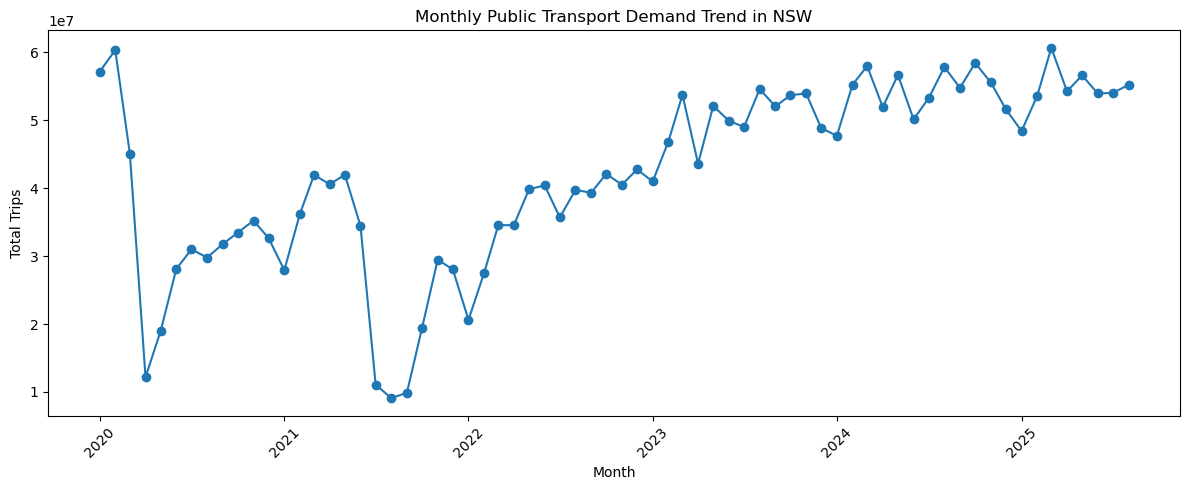

In [59]:
# ==============================
# 43. Chart: Monthly Demand Trend
# ==============================

monthly_demand["date"] = pd.to_datetime(
    monthly_demand["year"].astype(str) + "-" +
    monthly_demand["month"].astype(str).str.zfill(2) + "-01"
)

plt.figure(figsize=(12, 5))
plt.plot(monthly_demand["date"], monthly_demand["total_trips"], marker="o")
plt.title("Monthly Public Transport Demand Trend in NSW")
plt.xlabel("Month")
plt.ylabel("Total Trips")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(CHART_DIR / "monthly_demand_trend.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight: Monthly Demand Trend

The monthly demand trend shows how public transport usage changed over time. This view is useful for identifying seasonal demand patterns, long-term recovery trends and potential abnormal periods. For transport operations teams, monthly demand monitoring supports capacity planning, network performance review and strategic resource allocation.

###  Figure2. Demand by Transport Mode 交通方式需求对比

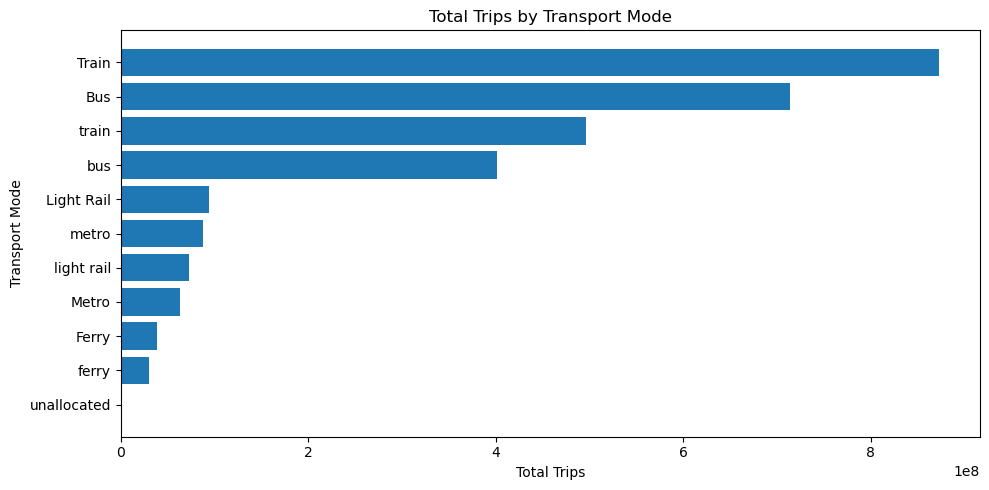

In [60]:
# ==============================
# 44. Chart: Demand by Transport Mode
# ==============================

mode_demand_plot = mode_demand.sort_values("total_trips", ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(mode_demand_plot["transport_mode"], mode_demand_plot["total_trips"])
plt.title("Total Trips by Transport Mode")
plt.xlabel("Total Trips")
plt.ylabel("Transport Mode")
plt.tight_layout()

plt.savefig(CHART_DIR / "transport_mode_demand.png", dpi=300, bbox_inches="tight")
plt.show()

###  Figure3. Card Type Demand Composition 乘客类型需求对比

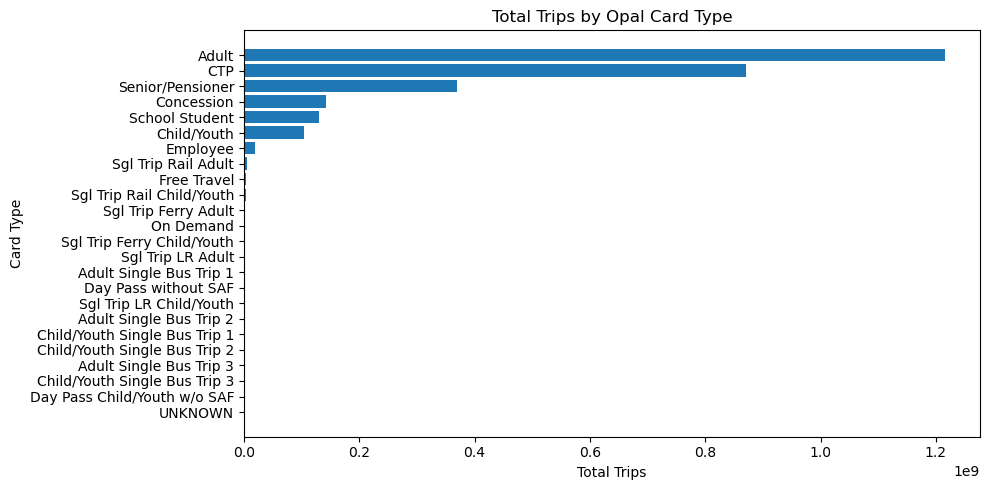

In [61]:
# ==============================
# 45. Chart: Card Type Demand
# ==============================

card_type_plot = card_type_demand.sort_values("total_trips", ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(card_type_plot["card_type"], card_type_plot["total_trips"])
plt.title("Total Trips by Opal Card Type")
plt.xlabel("Total Trips")
plt.ylabel("Card Type")
plt.tight_layout()

plt.savefig(CHART_DIR / "card_type_demand.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight: Card Type Demand

Card type demand helps understand the passenger composition of the public transport network. Adult passengers usually represent the largest commuting group, while concession, child/youth and senior card types provide additional insight into student, elderly and discounted travel patterns.

###  Figure4. Yearly Mode Demand Trend 不同交通方式年度变化

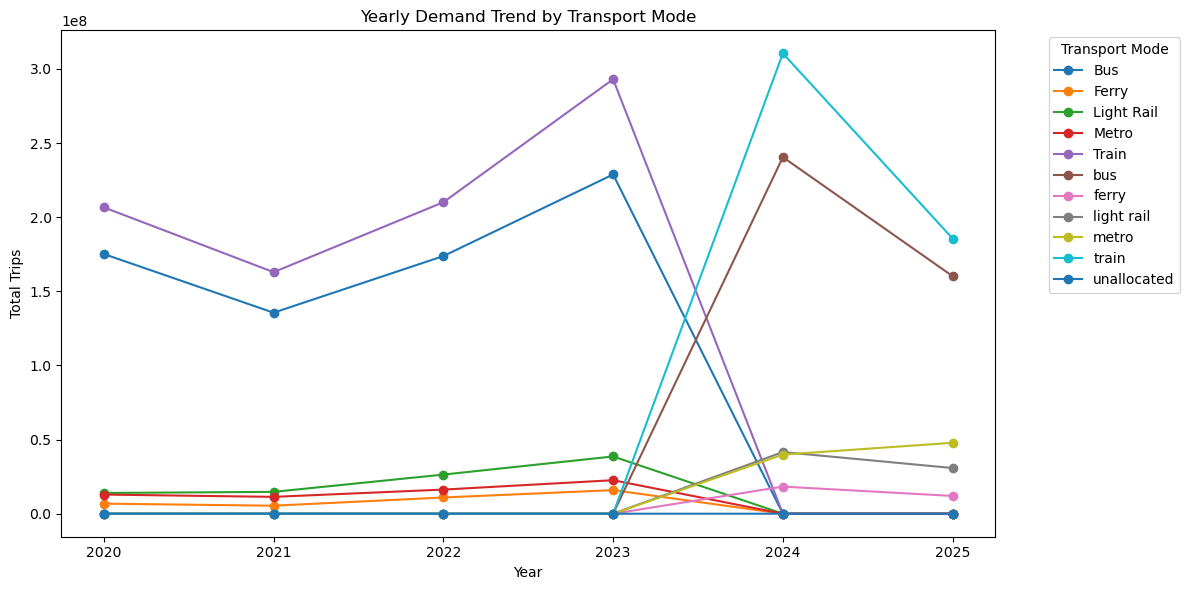

In [62]:
# ==============================
# 46. Chart: Yearly Demand by Transport Mode
# ==============================

yearly_mode_pivot = yearly_mode_demand.pivot(
    index="year",
    columns="transport_mode",
    values="total_trips"
).fillna(0)

plt.figure(figsize=(12, 6))

for mode in yearly_mode_pivot.columns:
    plt.plot(
        yearly_mode_pivot.index,
        yearly_mode_pivot[mode],
        marker="o",
        label=mode
    )

plt.title("Yearly Demand Trend by Transport Mode")
plt.xlabel("Year")
plt.ylabel("Total Trips")
plt.legend(title="Transport Mode", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.savefig(CHART_DIR / "yearly_mode_demand.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight: Yearly Demand by Mode

Yearly mode-level demand shows how different transport services changed over time. This supports recovery analysis, long-term capacity planning and mode-specific operational review. A strong increase in one transport mode may indicate changing travel behaviour, network improvements or shifts in commuter preferences.

###  Figure5. Top Station Flow

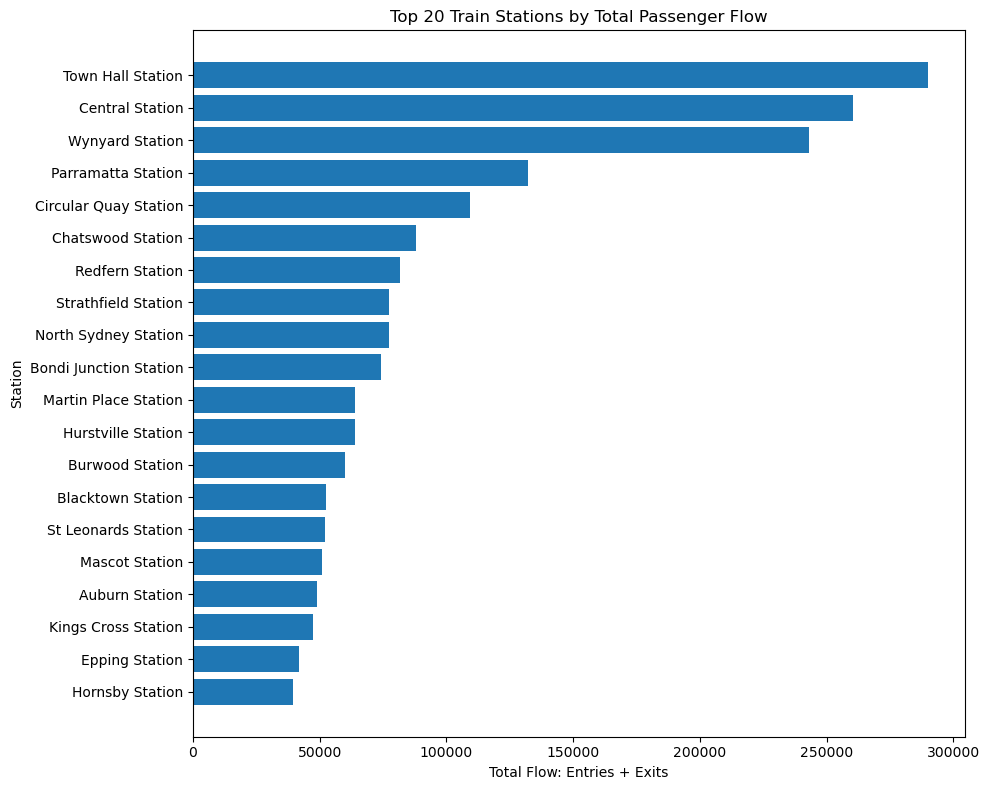

In [63]:
# ==============================
# 47. Chart: Top Stations by Total Flow
# ==============================

top_station_plot = top_station_flow.sort_values("total_flow", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(top_station_plot["station_name"], top_station_plot["total_flow"])
plt.title("Top 20 Train Stations by Total Passenger Flow")
plt.xlabel("Total Flow: Entries + Exits")
plt.ylabel("Station")
plt.tight_layout()

plt.savefig(CHART_DIR / "top_station_flow.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight: Top Station Flow

The top station flow ranking identifies the busiest train stations by combined entries and exits. These stations can be interpreted as key network pressure points because they handle the largest passenger volumes. For operations teams, this ranking supports crowd management, service monitoring and station-level resource allocation.

###  Figure6. Peak Station Pressure

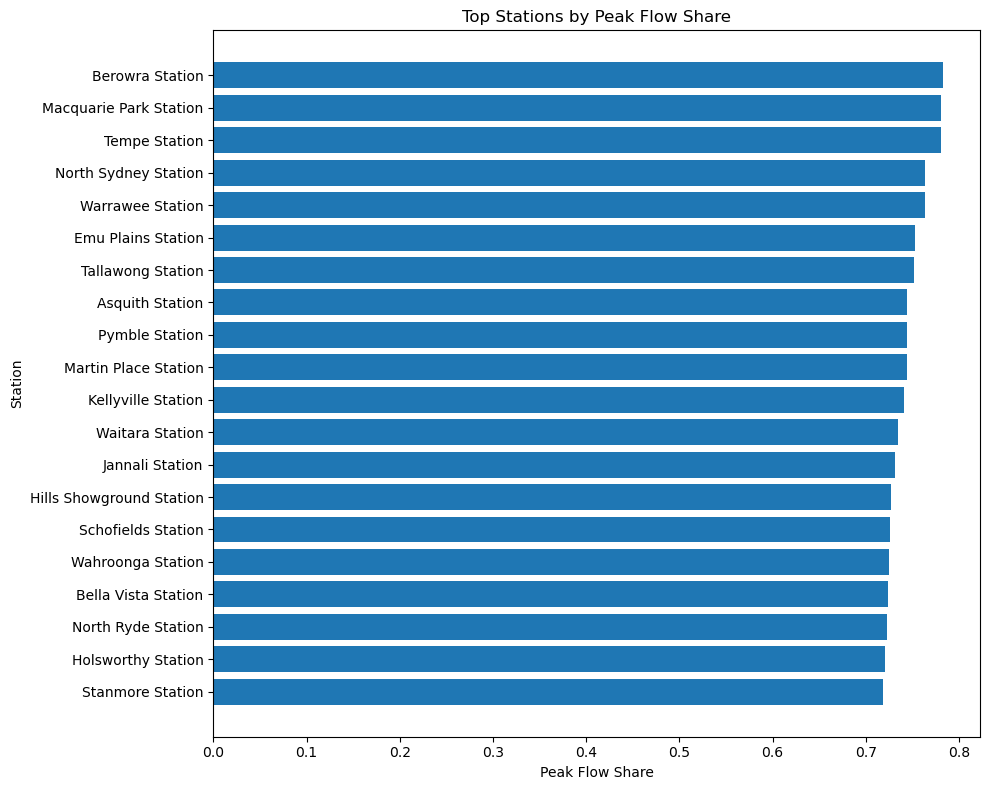

In [64]:
# ==============================
# 48. Chart: Peak Station Pressure
# ==============================

peak_pressure_plot = peak_station_pressure.sort_values("peak_flow_share", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(peak_pressure_plot["station_name"], peak_pressure_plot["peak_flow_share"])
plt.title("Top Stations by Peak Flow Share")
plt.xlabel("Peak Flow Share")
plt.ylabel("Station")
plt.tight_layout()

plt.savefig(CHART_DIR / "peak_station_pressure.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight: Peak Station Pressure

Peak flow share measures the proportion of station flow concentrated during morning and evening peak windows. A high peak flow share suggests that a station experiences concentrated demand within short periods, creating potential crowding, staffing or service-frequency pressure.

###  Figure7 Entry-Exit Imbalance

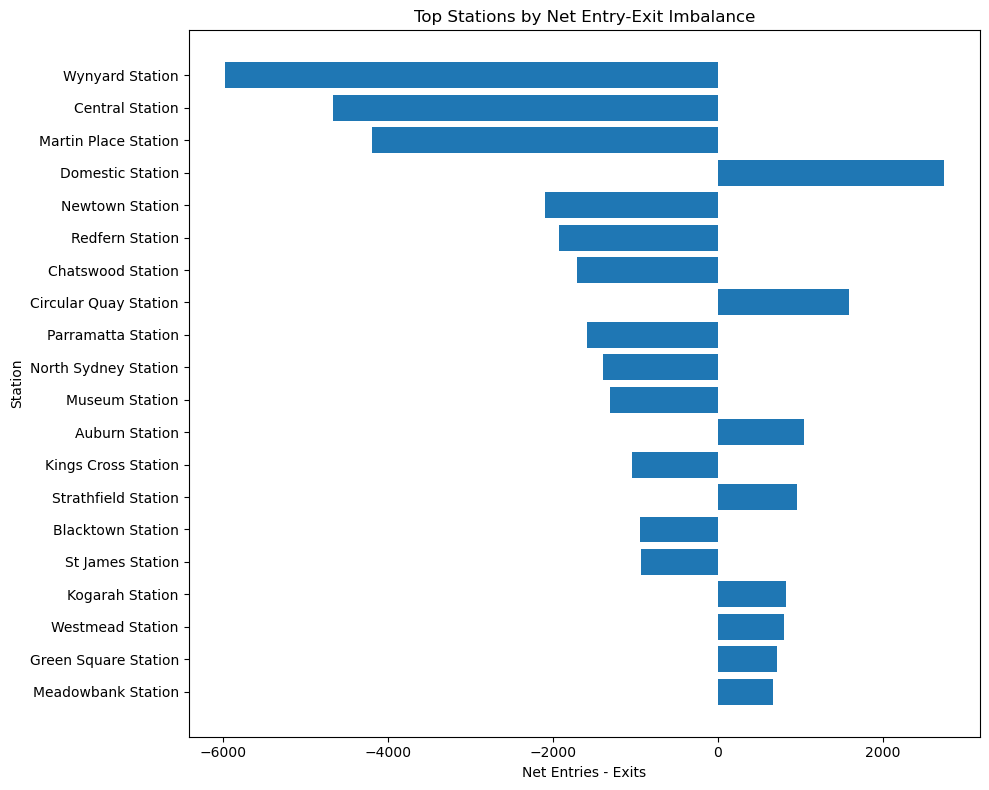

In [65]:
# ==============================
# 49. Chart: Entry-Exit Imbalance
# ==============================

imbalance_plot = entry_exit_imbalance.sort_values("abs_imbalance", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(imbalance_plot["station_name"], imbalance_plot["net_entry_exit_imbalance"])
plt.title("Top Stations by Net Entry-Exit Imbalance")
plt.xlabel("Net Entries - Exits")
plt.ylabel("Station")
plt.tight_layout()

plt.savefig(CHART_DIR / "entry_exit_imbalance.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight: Entry-Exit Imbalance

Entry-exit imbalance indicates whether a station has more entries or exits over the observed period. A positive value means more entries than exits, while a negative value means more exits than entries. This can help distinguish residential departure stations from employment or activity-centre arrival stations.

###  Figure8 Yearly Station Flow Trend

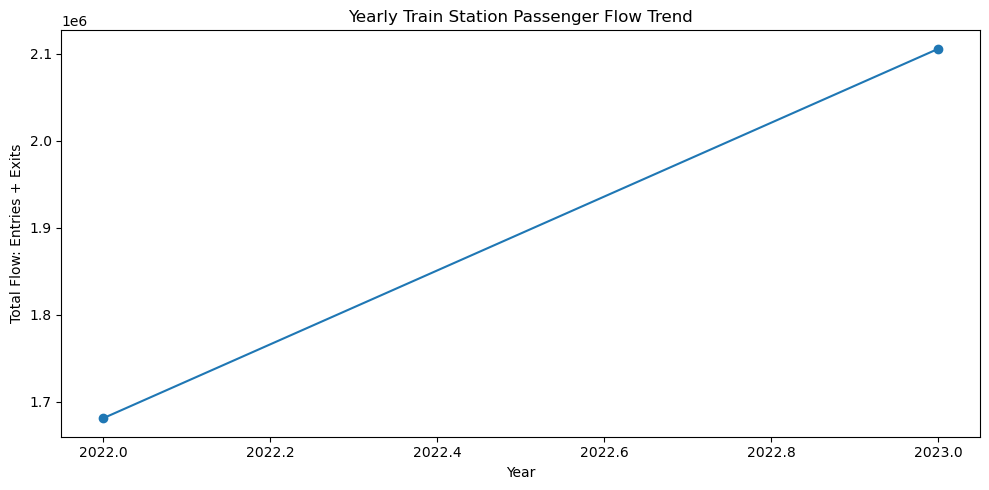

In [66]:
# ==============================
# 50. Chart: Yearly Station Flow Trend
# ==============================

plt.figure(figsize=(10, 5))
plt.plot(yearly_station_flow["year"], yearly_station_flow["total_flow"], marker="o")
plt.title("Yearly Train Station Passenger Flow Trend")
plt.xlabel("Year")
plt.ylabel("Total Flow: Entries + Exits")
plt.tight_layout()

plt.savefig(CHART_DIR / "yearly_station_flow_trend.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight: Yearly Station Flow Trend

The yearly station flow trend provides a high-level view of passenger movement across train stations. This can be used to monitor changes in network activity and evaluate whether station-level demand is increasing, decreasing or stabilising over time.

###  Figure9. Weather Impact Analysis

In [67]:
# ==============================
# 51. Create Monthly Weather Features
# ==============================

dim_weather = pd.read_csv(FINAL_DIR / "dim_weather.csv")
dim_weather["date"] = pd.to_datetime(dim_weather["date"])

dim_weather["year"] = dim_weather["date"].dt.year
dim_weather["month"] = dim_weather["date"].dt.month
dim_weather["month_id"] = (
    dim_weather["year"].astype(str)
    + "-"
    + dim_weather["month"].astype(str).str.zfill(2)
)

monthly_weather = (
    dim_weather.groupby(["year", "month", "month_id"], as_index=False)
    .agg(
        avg_rainfall_mm=("rainfall_mm", "mean"),
        total_rainfall_mm=("rainfall_mm", "sum"),
        rainy_days=("is_rainy", "sum"),
        avg_max_temp=("max_temp", "mean"),
        avg_min_temp=("min_temp", "mean")
    )
)

display(monthly_weather.head())

,year,month,month_id,avg_rainfall_mm,total_rainfall_mm,rainy_days,avg_max_temp,avg_min_temp
0,2020,1,2020-01,2.05,63.40,11,28.98,20.44
1,2020,2,2020-02,13.63,395.20,17,27.47,19.96
2,2020,3,2020-03,4.43,137.40,19,25.54,17.71
3,2020,4,2020-04,1.08,32.40,10,24.80,15.40
4,2020,5,2020-05,3.59,111.20,12,20.04,11.51


In [68]:
# ==============================
# 52. Merge Monthly Demand with Weather
# ==============================

monthly_demand_weather = monthly_demand.copy()

monthly_demand_weather["month_id"] = (
    monthly_demand_weather["year"].astype(str)
    + "-"
    + monthly_demand_weather["month"].astype(str).str.zfill(2)
)

monthly_demand_weather = monthly_demand_weather.merge(
    monthly_weather,
    on=["year", "month", "month_id"],
    how="left"
)

display(monthly_demand_weather.head())
display(monthly_demand_weather.isna().sum())

monthly_demand_weather.to_csv(
    SQL_EXPORT_DIR / "monthly_demand_weather.csv",
    index=False
)

print("Exported: monthly_demand_weather.csv")

,year,month,month_name,total_trips,date,month_id,avg_rainfall_mm,total_rainfall_mm,rainy_days,avg_max_temp,avg_min_temp
0,2020,1,January,"57,098,170.00",2020-01-01,2020-01,2.05,63.40,11,28.98,20.44
1,2020,2,February,"60,289,465.00",2020-02-01,2020-02,13.63,395.20,17,27.47,19.96
2,2020,3,March,"45,048,295.00",2020-03-01,2020-03,4.43,137.40,19,25.54,17.71
3,2020,4,April,"12,186,661.00",2020-04-01,2020-04,1.08,32.40,10,24.80,15.40
4,2020,5,May,"18,970,297.00",2020-05-01,2020-05,3.59,111.20,12,20.04,11.51


year                 0
month                0
month_name           0
total_trips          0
date                 0
month_id             0
avg_rainfall_mm      0
total_rainfall_mm    0
rainy_days           0
avg_max_temp         0
avg_min_temp         0
dtype: int64

Exported: monthly_demand_weather.csv


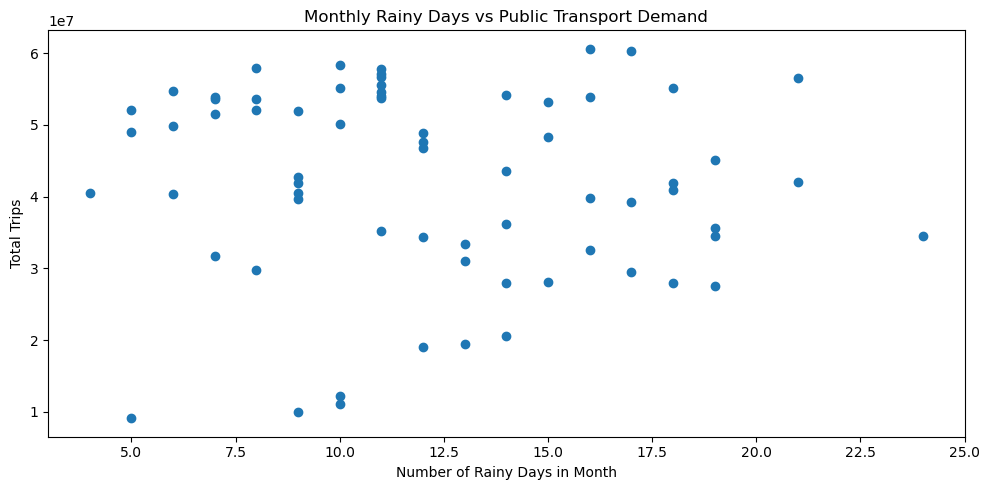

In [69]:
# ==============================
# 53. Chart: Rainy Days vs Monthly Demand
# ==============================

plt.figure(figsize=(10, 5))
plt.scatter(
    monthly_demand_weather["rainy_days"],
    monthly_demand_weather["total_trips"]
)
plt.title("Monthly Rainy Days vs Public Transport Demand")
plt.xlabel("Number of Rainy Days in Month")
plt.ylabel("Total Trips")
plt.tight_layout()

plt.savefig(CHART_DIR / "rainy_days_vs_demand.png", dpi=300, bbox_inches="tight")
plt.show()

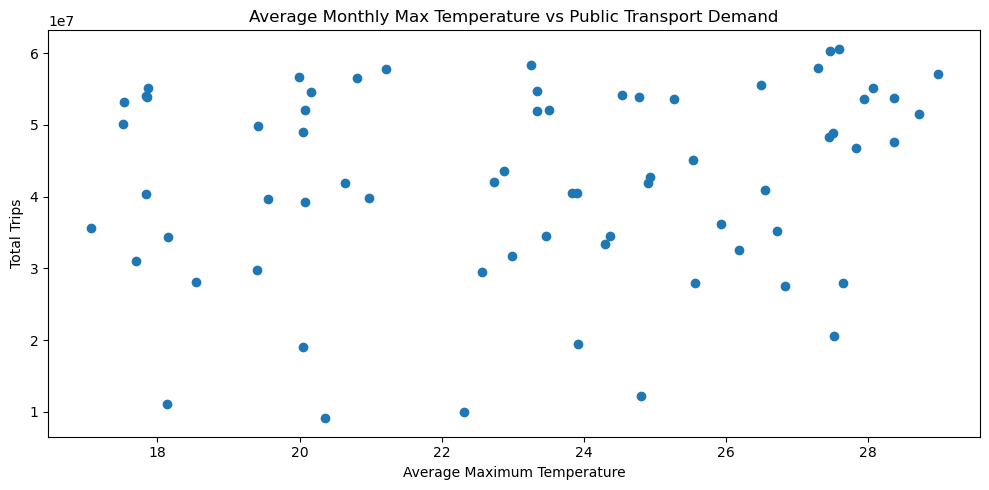

In [70]:
# ==============================
# 54. Chart: Average Max Temperature vs Monthly Demand
# ==============================

plt.figure(figsize=(10, 5))
plt.scatter(
    monthly_demand_weather["avg_max_temp"],
    monthly_demand_weather["total_trips"]
)
plt.title("Average Monthly Max Temperature vs Public Transport Demand")
plt.xlabel("Average Maximum Temperature")
plt.ylabel("Total Trips")
plt.tight_layout()

plt.savefig(CHART_DIR / "temperature_vs_demand.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight: Weather Impact

Weather features provide a useful external context for transport demand analysis. By aggregating daily weather observations into monthly rainfall and temperature indicators, we can explore whether wetter or hotter months are associated with changes in public transport usage. This type of analysis supports operational planning under different environmental conditions.

###  Figure10.  Data Quality Chart

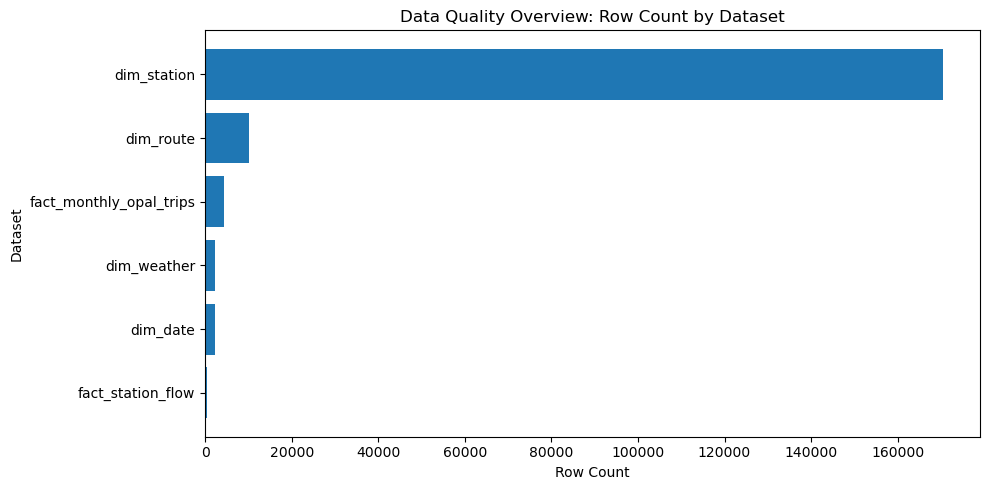

In [71]:
# ==============================
# 55. Chart: Data Quality Summary
# ==============================

dq_plot = data_quality_summary.sort_values("row_count", ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(dq_plot["dataset"], dq_plot["row_count"])
plt.title("Data Quality Overview: Row Count by Dataset")
plt.xlabel("Row Count")
plt.ylabel("Dataset")
plt.tight_layout()

plt.savefig(CHART_DIR / "data_quality_row_count.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight: Data Quality Overview

The data quality overview summarises the size and duplicate checks of the main analytical tables. This supports risk-aware delivery by making data coverage and table-level limitations visible before dashboard reporting and model development.

In [72]:
# ==============================
# 56. Check Exported Charts
# ==============================

print("Exported chart files:")
for file in sorted(CHART_DIR.glob("*.png")):
    print("-", file.name)

Exported chart files:
- card_type_demand.png
- data_quality_row_count.png
- entry_exit_imbalance.png
- monthly_demand_trend.png
- peak_station_pressure.png
- rainy_days_vs_demand.png
- temperature_vs_demand.png
- top_station_flow.png
- transport_mode_demand.png
- yearly_mode_demand.png
- yearly_station_flow_trend.png


# Step 5：Machine Learning Demand Forecasting

预测每个月、每种交通方式的 trip_count，因为Opal 数据是 monthly + transport_mode + card_type 粒度，所以这是最合理、最稳的预测方式。

## 9. Machine Learning Demand Forecasting

This section builds machine learning models to forecast monthly public transport demand. The forecasting workflow uses calendar features, weather indicators and lagged demand features to predict future monthly trips by transport mode.

The models include:

1. Naive baseline model
2. Linear Regression
3. Random Forest Regressor

The goal is not only to maximise prediction accuracy, but also to demonstrate a practical forecasting workflow that can support transport operations planning.

In [73]:
# ==============================
# 57. Import Machine Learning Libraries
# ==============================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Machine learning libraries imported successfully.")

Machine learning libraries imported successfully.


In [74]:
# ==============================
# 58. Prepare Monthly Demand Forecasting Dataset
# ==============================

# Load final fact table
fact_monthly_opal_trips = pd.read_csv(FINAL_DIR / "fact_monthly_opal_trips.csv")
fact_monthly_opal_trips["year_month"] = pd.to_datetime(fact_monthly_opal_trips["year_month"])

# Aggregate demand by month and transport mode
forecast_df = (
    fact_monthly_opal_trips
    .groupby(["year_month", "year", "month", "month_name", "transport_mode"], as_index=False)
    .agg(trip_count=("trip_count", "sum"))
)

# Create month_id
forecast_df["month_id"] = (
    forecast_df["year"].astype(str)
    + "-"
    + forecast_df["month"].astype(str).str.zfill(2)
)

# Load monthly weather features generated earlier
monthly_weather = pd.read_csv(SQL_EXPORT_DIR / "monthly_demand_weather.csv")

# Keep only weather columns
monthly_weather_features = monthly_weather[
    [
        "month_id",
        "avg_rainfall_mm",
        "total_rainfall_mm",
        "rainy_days",
        "avg_max_temp",
        "avg_min_temp"
    ]
].drop_duplicates()

# Merge weather features
forecast_df = forecast_df.merge(
    monthly_weather_features,
    on="month_id",
    how="left"
)

# Sort for lag feature creation
forecast_df = forecast_df.sort_values(["transport_mode", "year_month"]).reset_index(drop=True)

print("Forecasting dataset created:")
print(forecast_df.shape)
display(forecast_df.head())
display(forecast_df.tail())

Forecasting dataset created:
(348, 12)


,year_month,year,month,month_name,transport_mode,trip_count,month_id,avg_rainfall_mm,total_rainfall_mm,rainy_days,avg_max_temp,avg_min_temp
0,2020-01-01,2020,1,January,Bus,"22,130,032.00",2020-01,2.05,63.40,11,28.98,20.44
1,2020-02-01,2020,2,February,Bus,"25,206,493.00",2020-02,13.63,395.20,17,27.47,19.96
2,2020-03-01,2020,3,March,Bus,"19,191,569.00",2020-03,4.43,137.40,19,25.54,17.71
3,2020-04-01,2020,4,April,Bus,"5,504,822.00",2020-04,1.08,32.40,10,24.80,15.40
4,2020-05-01,2020,5,May,Bus,"8,549,735.00",2020-05,3.59,111.20,12,20.04,11.51


,year_month,year,month,month_name,transport_mode,trip_count,month_id,avg_rainfall_mm,total_rainfall_mm,rainy_days,avg_max_temp,avg_min_temp
343,2024-04-01,2024,4,April,unallocated,10.00,2024-04,6.21,186.20,9,23.34,15.38
344,2024-05-01,2024,5,May,unallocated,41.00,2024-05,7.15,221.60,11,19.99,12.38
345,2024-06-01,2024,6,June,unallocated,46.00,2024-06,10.38,311.40,10,17.52,9.29
346,2024-07-01,2024,7,July,unallocated,49.00,2024-07,2.73,84.60,15,17.54,9.45
347,2025-05-01,2025,5,May,unallocated,630.00,2025-05,6.87,213.00,21,20.80,13.92


### 生成时间特征和滞后特征

这里是 ML 项目的核心。我们会加：lag_1_demand      上个月需求

lag_3_demand      前 3 个月需求

rolling_3m_avg    过去 3 个月平均需求

rolling_6m_avg    过去 6 个月平均需求

In [75]:
# ==============================
# 59. Feature Engineering for Forecasting
# ==============================

forecast_features = forecast_df.copy()

# Calendar features
forecast_features["quarter"] = forecast_features["year_month"].dt.quarter
forecast_features["month_num"] = forecast_features["year_month"].dt.month

# Australian season mapping
def assign_season_from_month(month):
    if month in [12, 1, 2]:
        return "Summer"
    elif month in [3, 4, 5]:
        return "Autumn"
    elif month in [6, 7, 8]:
        return "Winter"
    else:
        return "Spring"

forecast_features["season"] = forecast_features["month_num"].apply(assign_season_from_month)

# Lag and rolling features by transport mode
forecast_features["lag_1_demand"] = (
    forecast_features
    .groupby("transport_mode")["trip_count"]
    .shift(1)
)

forecast_features["lag_3_demand"] = (
    forecast_features
    .groupby("transport_mode")["trip_count"]
    .shift(3)
)

forecast_features["rolling_3m_avg"] = (
    forecast_features
    .groupby("transport_mode")["trip_count"]
    .transform(lambda x: x.shift(1).rolling(window=3).mean())
)

forecast_features["rolling_6m_avg"] = (
    forecast_features
    .groupby("transport_mode")["trip_count"]
    .transform(lambda x: x.shift(1).rolling(window=6).mean())
)

# Drop rows where lag features are missing
forecast_features = forecast_features.dropna(subset=[
    "lag_1_demand",
    "lag_3_demand",
    "rolling_3m_avg",
    "rolling_6m_avg"
]).copy()

print("Forecasting features created:")
print(forecast_features.shape)
display(forecast_features.head())

Forecasting features created:
(282, 19)


,year_month,year,month,month_name,transport_mode,trip_count,month_id,avg_rainfall_mm,total_rainfall_mm,rainy_days,avg_max_temp,avg_min_temp,quarter,month_num,season,lag_1_demand,lag_3_demand,rolling_3m_avg,rolling_6m_avg
6,2020-07-01,2020,7,July,Bus,"13,132,371.00",2020-07,4.11,127.40,13,17.70,9.78,3,7,Winter,"12,386,023.00","5,504,822.00","8,813,526.67","15,494,779.00"
7,2020-08-01,2020,8,August,Bus,"13,107,189.00",2020-08,2.11,65.40,8,19.40,9.37,3,8,Winter,"13,132,371.00","8,549,735.00","11,356,043.00","13,995,168.83"
8,2020-09-01,2020,9,September,Bus,"13,690,626.00",2020-09,1.03,31.00,7,22.99,12.89,3,9,Spring,"13,107,189.00","12,386,023.00","12,875,194.33","11,978,618.17"
9,2020-10-01,2020,10,October,Bus,"14,059,038.00",2020-10,2.10,65.20,13,24.30,15.25,4,10,Spring,"13,690,626.00","13,132,371.00","13,310,062.00","11,061,794.33"
10,2020-11-01,2020,11,November,Bus,"14,809,745.00",2020-11,1.39,41.80,11,26.72,16.98,4,11,Spring,"14,059,038.00","13,107,189.00","13,618,951.00","12,487,497.00"


### 定义训练集和测试集，时间序列不要随机切分，我们用：2020–2024 训练，2025 测试

In [81]:
# ==============================
# 60. Train-Test Split by Time
# ==============================

target_col = "trip_count"

feature_cols = [
    "year",
    "month_num",
    "quarter",
    "transport_mode",
    "season",
    "avg_rainfall_mm",
    "total_rainfall_mm",
    "rainy_days",
    "avg_max_temp",
    "avg_min_temp",
    "lag_1_demand",
    "lag_3_demand",
    "rolling_3m_avg",
    "rolling_6m_avg"
]

# Avoid duplicated columns by building the column list carefully
base_cols = ["year_month", "month_id", target_col]

model_cols = base_cols + feature_cols

# Remove duplicates while preserving order
model_cols = list(dict.fromkeys(model_cols))

model_data = forecast_features[model_cols].copy()

# Check duplicated columns
print("Duplicated columns:", model_data.columns[model_data.columns.duplicated()].tolist())

# Train on years before 2025, test on 2025
train_data = model_data[model_data["year"] < 2025].copy()
test_data = model_data[model_data["year"] == 2025].copy()

X_train = train_data[feature_cols]
y_train = train_data[target_col]

X_test = test_data[feature_cols]
y_test = test_data[target_col]

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

display(train_data.head())
display(test_data.head())

Duplicated columns: []
Training data: (241, 14)
Testing data: (41, 14)


,year_month,month_id,trip_count,year,month_num,quarter,transport_mode,season,avg_rainfall_mm,total_rainfall_mm,rainy_days,avg_max_temp,avg_min_temp,lag_1_demand,lag_3_demand,rolling_3m_avg,rolling_6m_avg
6,2020-07-01,2020-07,"13,132,371.00",2020,7,3,Bus,Winter,4.11,127.40,13,17.70,9.78,"12,386,023.00","5,504,822.00","8,813,526.67","15,494,779.00"
7,2020-08-01,2020-08,"13,107,189.00",2020,8,3,Bus,Winter,2.11,65.40,8,19.40,9.37,"13,132,371.00","8,549,735.00","11,356,043.00","13,995,168.83"
8,2020-09-01,2020-09,"13,690,626.00",2020,9,3,Bus,Spring,1.03,31.00,7,22.99,12.89,"13,107,189.00","12,386,023.00","12,875,194.33","11,978,618.17"
9,2020-10-01,2020-10,"14,059,038.00",2020,10,4,Bus,Spring,2.10,65.20,13,24.30,15.25,"13,690,626.00","13,132,371.00","13,310,062.00","11,061,794.33"
10,2020-11-01,2020-11,"14,809,745.00",2020,11,4,Bus,Spring,1.39,41.80,11,26.72,16.98,"14,059,038.00","13,107,189.00","13,618,951.00","12,487,497.00"


,year_month,month_id,trip_count,year,month_num,quarter,transport_mode,season,avg_rainfall_mm,total_rainfall_mm,rainy_days,avg_max_temp,avg_min_temp,lag_1_demand,lag_3_demand,rolling_3m_avg,rolling_6m_avg
252,2025-01-01,2025-01,"17,977,339.00",2025,1,1,bus,Summer,5.05,156.40,15,27.45,19.46,"18,879,816.00","20,937,640.00","20,157,907.33","20,219,127.50"
253,2025-02-01,2025-02,"20,531,077.00",2025,2,1,bus,Summer,1.92,53.80,7,27.94,19.92,"17,977,339.00","20,656,266.00","19,171,140.33","19,934,083.33"
254,2025-03-01,2025-03,"22,682,915.00",2025,3,1,bus,Autumn,4.01,124.20,16,27.59,19.83,"20,531,077.00","18,879,816.00","19,129,410.67","19,848,941.17"
255,2025-04-01,2025-04,"19,448,383.00",2025,4,2,bus,Autumn,4.38,131.40,14,24.54,16.62,"22,682,915.00","17,977,339.00","20,397,110.33","20,277,508.83"
256,2025-05-01,2025-05,"21,038,784.00",2025,5,2,bus,Autumn,6.87,213.00,21,20.80,13.92,"19,448,383.00","20,531,077.00","20,887,458.33","20,029,299.33"


In [82]:
# ==============================
# 61. Define Evaluation Metrics
# ==============================

def mean_absolute_percentage_error(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Avoid division by zero
    non_zero_mask = y_true != 0
    
    if non_zero_mask.sum() == 0:
        return np.nan
    
    return np.mean(
        np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])
    ) * 100


def evaluate_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    return {
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "R2": r2
    }

### Naive Baseline Model 用上个月需求预测本月需求

In [83]:
# ==============================
# 62. Baseline Model: Previous Month Demand
# ==============================

baseline_pred = test_data["lag_1_demand"].values

baseline_metrics = evaluate_model(
    "Naive Baseline",
    y_test,
    baseline_pred
)

baseline_metrics

{'model': 'Naive Baseline',
 'MAE': 772661.5139024393,
 'RMSE': np.float64(1232682.3095644535),
 'MAPE': np.float64(9.026374677750336),
 'R2': 0.9812742026227906}

### Linear Regression Model

In [84]:
# ==============================
# 63. Linear Regression Forecasting Model
# ==============================

categorical_features = ["transport_mode", "season"]

numeric_features = [
    "year",
    "month_num",
    "quarter",
    "avg_rainfall_mm",
    "total_rainfall_mm",
    "rainy_days",
    "avg_max_temp",
    "avg_min_temp",
    "lag_1_demand",
    "lag_3_demand",
    "rolling_3m_avg",
    "rolling_6m_avg"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

linear_metrics = evaluate_model(
    "Linear Regression",
    y_test,
    linear_pred
)

linear_metrics

{'model': 'Linear Regression',
 'MAE': 860998.4771165279,
 'RMSE': np.float64(1175742.6617037777),
 'MAPE': np.float64(4985.540269352006),
 'R2': 0.9829641994583144}

### Random Forest Model

In [85]:
# ==============================
# 64. Random Forest Forecasting Model
# ==============================

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=300,
            max_depth=8,
            random_state=42
        ))
    ]
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_metrics = evaluate_model(
    "Random Forest",
    y_test,
    rf_pred
)

rf_metrics

{'model': 'Random Forest',
 'MAE': 1145300.5065531067,
 'RMSE': np.float64(1576408.1417345852),
 'MAPE': np.float64(1131.9983567064794),
 'R2': 0.9693750540114049}

### 汇总模型结果并导出 model_metrics.csv

In [86]:
# ==============================
# 65. Compare Model Performance
# ==============================

model_metrics = pd.DataFrame([
    baseline_metrics,
    linear_metrics,
    rf_metrics
])

model_metrics = model_metrics.sort_values("RMSE")

display(model_metrics)

model_metrics.to_csv(MODEL_RESULT_DIR / "model_metrics.csv", index=False)

print("Exported: model_metrics.csv")

,model,MAE,RMSE,MAPE,R2
1,Linear Regression,"860,998.48","1,175,742.66","4,985.54",0.98
0,Naive Baseline,"772,661.51","1,232,682.31",9.03,0.98
2,Random Forest,"1,145,300.51","1,576,408.14","1,132.00",0.97


Exported: model_metrics.csv


In [87]:
# ==============================
# 66. Export Forecast Results
# ==============================

forecast_results = test_data[
    [
        "year_month",
        "month_id",
        "transport_mode",
        "trip_count",
        "lag_1_demand"
    ]
].copy()

forecast_results = forecast_results.rename(columns={
    "trip_count": "actual_demand",
    "lag_1_demand": "baseline_prediction"
})

forecast_results["linear_regression_prediction"] = linear_pred
forecast_results["random_forest_prediction"] = rf_pred

forecast_results["rf_error"] = (
    forecast_results["actual_demand"] -
    forecast_results["random_forest_prediction"]
)

forecast_results["rf_abs_error"] = forecast_results["rf_error"].abs()

forecast_results["rf_abs_percentage_error"] = np.where(
    forecast_results["actual_demand"] != 0,
    forecast_results["rf_abs_error"] / forecast_results["actual_demand"] * 100,
    np.nan
)

display(forecast_results.head())

forecast_results.to_csv(MODEL_RESULT_DIR / "forecast_results.csv", index=False)

print("Exported: forecast_results.csv")

,year_month,month_id,transport_mode,actual_demand,baseline_prediction,linear_regression_prediction,random_forest_prediction,rf_error,rf_abs_error,rf_abs_percentage_error
252,2025-01-01,2025-01,bus,"17,977,339.00","18,879,816.00","18,713,885.48","20,662,430.81","-2,685,091.81","2,685,091.81",14.94
253,2025-02-01,2025-02,bus,"20,531,077.00","17,977,339.00","18,772,486.93","20,726,861.75","-195,784.75","195,784.75",0.95
254,2025-03-01,2025-03,bus,"22,682,915.00","20,531,077.00","22,022,815.64","20,518,284.62","2,164,630.38","2,164,630.38",9.54
255,2025-04-01,2025-04,bus,"19,448,383.00","22,682,915.00","23,261,447.47","20,971,619.36","-1,523,236.36","1,523,236.36",7.83
256,2025-05-01,2025-05,bus,"21,038,784.00","19,448,383.00","20,179,087.80","21,317,695.07","-278,911.07","278,911.07",1.33


Exported: forecast_results.csv


In [88]:
# ==============================
# 67. Random Forest Feature Importance
# ==============================

# Get feature names after preprocessing
preprocessor_fitted = rf_model.named_steps["preprocessor"]
rf_fitted = rf_model.named_steps["model"]

cat_feature_names = (
    preprocessor_fitted
    .named_transformers_["cat"]
    .get_feature_names_out(categorical_features)
)

all_feature_names = list(cat_feature_names) + numeric_features

feature_importance = pd.DataFrame({
    "feature": all_feature_names,
    "importance": rf_fitted.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

display(feature_importance.head(20))

feature_importance.to_csv(MODEL_RESULT_DIR / "feature_importance.csv", index=False)

print("Exported: feature_importance.csv")

,feature,importance
23,lag_1_demand,0.93
25,rolling_3m_avg,0.03
26,rolling_6m_avg,0.02
24,lag_3_demand,0.01
22,avg_min_temp,0.01
21,avg_max_temp,0.00
20,rainy_days,0.00
15,year,0.00
16,month_num,0.00
18,avg_rainfall_mm,0.00


Exported: feature_importance.csv


### 画 Actual vs Predicted 图

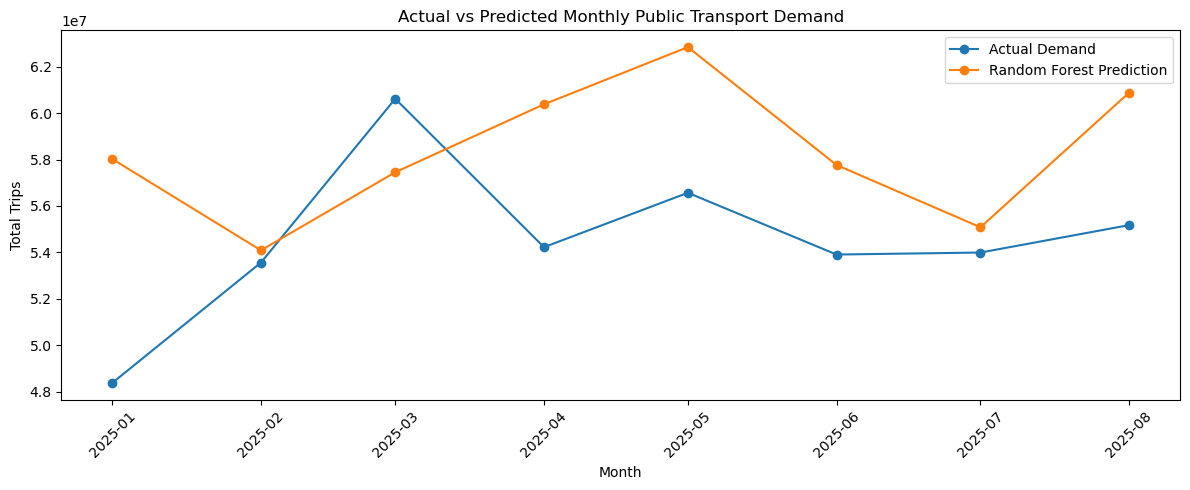

In [90]:
# ==============================
# 68. Chart: Actual vs Predicted Demand
# ==============================

# Aggregate actual and prediction by month for cleaner visualisation
forecast_plot = (
    forecast_results
    .groupby("year_month", as_index=False)
    .agg(
        actual_demand=("actual_demand", "sum"),
        random_forest_prediction=("random_forest_prediction", "sum"),
        linear_regression_prediction=("linear_regression_prediction", "sum"),
        baseline_prediction=("baseline_prediction", "sum")
    )
)

forecast_plot["year_month"] = pd.to_datetime(forecast_plot["year_month"])

plt.figure(figsize=(12, 5))
plt.plot(
    forecast_plot["year_month"],
    forecast_plot["actual_demand"],
    marker="o",
    label="Actual Demand"
)
plt.plot(
    forecast_plot["year_month"],
    forecast_plot["random_forest_prediction"],
    marker="o",
    label="Random Forest Prediction"
)

plt.title("Actual vs Predicted Monthly Public Transport Demand")
plt.xlabel("Month")
plt.ylabel("Total Trips")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(CHART_DIR / "actual_vs_predicted_demand.png", dpi=300, bbox_inches="tight")
plt.show()

### 画 Feature Importance 图

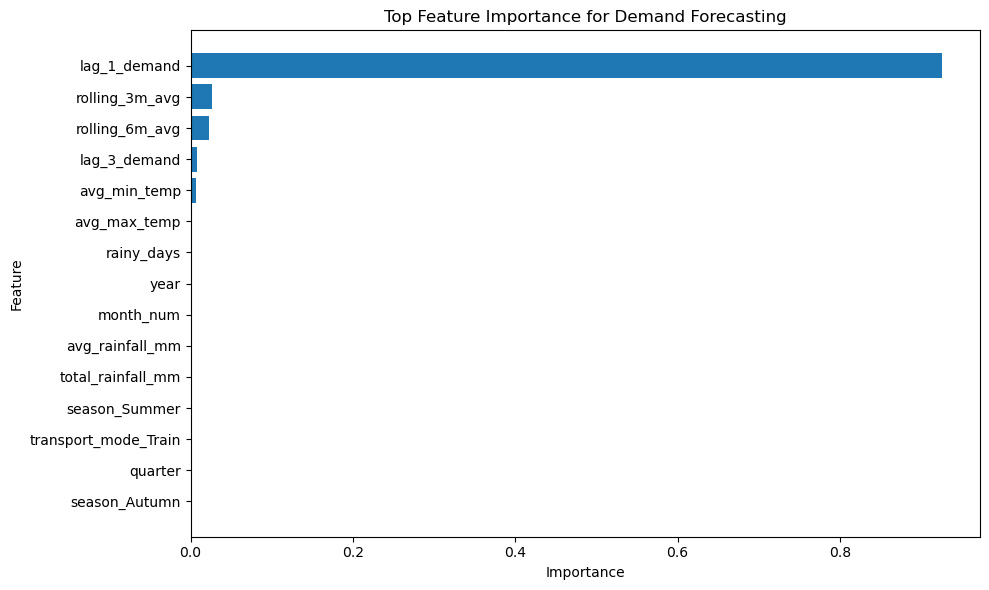

In [91]:
# ==============================
# 69. Chart: Random Forest Feature Importance
# ==============================

top_features = feature_importance.head(15).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.title("Top Feature Importance for Demand Forecasting")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(CHART_DIR / "feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

In [92]:
# ==============================
# 70. Check Exported Model Results
# ==============================

print("Model result files:")
for file in sorted(MODEL_RESULT_DIR.glob("*.csv")):
    print("-", file.name)

Model result files:
- feature_importance.csv
- forecast_results.csv
- model_metrics.csv


In [93]:
# ==============================
# 71. Check Forecasting Chart Files
# ==============================

print("Forecasting chart files:")
for file in sorted(CHART_DIR.glob("*.png")):
    if "predicted" in file.name or "feature_importance" in file.name:
        print("-", file.name)

Forecasting chart files:
- actual_vs_predicted_demand.png
- feature_importance.png


## 10. Export Tableau Dashboard Data

This section prepares dashboard-ready datasets for Tableau. The dashboard is designed with four pages:

1. Demand Overview  
2. Station Flow & Network Insights  
3. Forecasting & Operational Planning  
4. Data Quality & Risk Assessment  

### Demand Overview

In [94]:
# ==============================
# 72. Export Tableau Data: Demand Overview
# ==============================

# Monthly demand by transport mode
tableau_demand_overview = (
    fact_monthly_opal_trips
    .groupby(["year_month", "year", "month", "month_name", "transport_mode"], as_index=False)
    .agg(total_trips=("trip_count", "sum"))
)

# Add total demand by month for reference
monthly_total = (
    tableau_demand_overview
    .groupby("year_month", as_index=False)
    .agg(monthly_total_trips=("total_trips", "sum"))
)

tableau_demand_overview = tableau_demand_overview.merge(
    monthly_total,
    on="year_month",
    how="left"
)

# Add mode share
tableau_demand_overview["mode_share"] = np.where(
    tableau_demand_overview["monthly_total_trips"] > 0,
    tableau_demand_overview["total_trips"] / tableau_demand_overview["monthly_total_trips"],
    0
)

tableau_demand_overview.to_csv(
    DASHBOARD_DATA_DIR / "tableau_demand_overview.csv",
    index=False
)

print("Exported: tableau_demand_overview.csv")
display(tableau_demand_overview.head())

Exported: tableau_demand_overview.csv


,year_month,year,month,month_name,transport_mode,total_trips,monthly_total_trips,mode_share
0,2020-01-01,2020,1,January,Bus,"22,130,032.00","57,098,170.00",0.39
1,2020-01-01,2020,1,January,Ferry,"1,522,325.00","57,098,170.00",0.03
2,2020-01-01,2020,1,January,Light Rail,"2,180,906.00","57,098,170.00",0.04
3,2020-01-01,2020,1,January,Metro,"1,865,446.00","57,098,170.00",0.03
4,2020-01-01,2020,1,January,Train,"29,399,461.00","57,098,170.00",0.51


### Station Flow & Network Insights

In [95]:
# ==============================
# 73. Export Tableau Data: Station Flow
# ==============================

tableau_station_flow = fact_station_flow.copy()

# Try to enrich station flow with GTFS region and coordinates
station_location = dim_station[
    ["station_id", "stop_lat", "stop_lon", "region"]
].drop_duplicates(subset=["station_id"])

tableau_station_flow = tableau_station_flow.merge(
    station_location,
    on="station_id",
    how="left"
)

# If station coordinates are not matched, keep station flow data anyway
tableau_station_flow["region"] = tableau_station_flow["region"].fillna("Unmatched / Unknown")

# Create operational category
def classify_station_pressure(score):
    if score >= 0.70:
        return "High Peak Pressure"
    elif score >= 0.50:
        return "Medium Peak Pressure"
    else:
        return "Low Peak Pressure"

tableau_station_flow["pressure_category"] = tableau_station_flow["bottleneck_score"].apply(
    classify_station_pressure
)

tableau_station_flow.to_csv(
    DASHBOARD_DATA_DIR / "tableau_station_flow.csv",
    index=False
)

print("Exported: tableau_station_flow.csv")
display(tableau_station_flow.head())
print(tableau_station_flow["region"].value_counts().head())

Exported: tableau_station_flow.csv


,station_flow_id,year,station_id,station_name,morning_entries,morning_exits,midday_entries,midday_exits,evening_entries,evening_exits,night_entries,night_exits,total_entries,total_exits,total_flow,morning_total_flow,midday_total_flow,evening_total_flow,night_total_flow,peak_total_flow,entry_exit_imbalance,bottleneck_score,stop_lat,stop_lon,region,pressure_category
0,2022_adamstown,2022,adamstown,Adamstown Station,0,0,0,0,0,0,0,0,80,70,150,0,0,0,0,0,10,0.00,-32.93,151.72,Eastern Sydney,Low Peak Pressure
1,2022_albion_park,2022,albion_park,Albion Park Station,0,0,0,0,0,0,0,0,190,160,350,0,0,0,0,0,30,0.00,-34.56,150.80,Western Sydney,Low Peak Pressure
2,2022_allawah,2022,allawah,Allawah Station,920,160,390,230,310,750,230,530,1850,1670,3520,1080,620,1060,760,2140,180,0.61,-33.97,151.11,Northern Sydney,Medium Peak Pressure
3,2022_arncliffe,2022,arncliffe,Arncliffe Station,860,140,280,200,290,700,120,300,1550,1340,2890,1000,480,990,420,1990,210,0.69,-33.94,151.15,Northern Sydney,Medium Peak Pressure
4,2022_artarmon,2022,artarmon,Artarmon Station,1600,500,650,610,960,1490,250,750,3460,3350,6810,2100,1260,2450,1000,4550,110,0.67,-33.81,151.18,Southern Sydney,Medium Peak Pressure


region
Western Sydney     240
Northern Sydney    122
Eastern Sydney      61
Southern Sydney     61
Sydney CBD          24
Name: count, dtype: int64


### Forecasting & Operational Planning

In [96]:
# ==============================
# 74. Export Tableau Data: Forecasting
# ==============================

forecast_results = pd.read_csv(MODEL_RESULT_DIR / "forecast_results.csv")
model_metrics = pd.read_csv(MODEL_RESULT_DIR / "model_metrics.csv")
feature_importance = pd.read_csv(MODEL_RESULT_DIR / "feature_importance.csv")

# Forecast result table
tableau_forecasting = forecast_results.copy()

# Add month for Tableau sorting
tableau_forecasting["year_month"] = pd.to_datetime(tableau_forecasting["year_month"])
tableau_forecasting["year"] = tableau_forecasting["year_month"].dt.year
tableau_forecasting["month"] = tableau_forecasting["year_month"].dt.month
tableau_forecasting["month_name"] = tableau_forecasting["year_month"].dt.month_name()

# Add demand risk category based on prediction error
def classify_forecast_error(mape):
    if pd.isna(mape):
        return "Unknown"
    elif mape >= 20:
        return "High Forecast Error"
    elif mape >= 10:
        return "Medium Forecast Error"
    else:
        return "Low Forecast Error"

tableau_forecasting["forecast_error_category"] = tableau_forecasting[
    "rf_abs_percentage_error"
].apply(classify_forecast_error)

tableau_forecasting.to_csv(
    DASHBOARD_DATA_DIR / "tableau_forecasting.csv",
    index=False
)

# Also export model metrics and feature importance for Tableau
model_metrics.to_csv(
    DASHBOARD_DATA_DIR / "tableau_model_metrics.csv",
    index=False
)

feature_importance.to_csv(
    DASHBOARD_DATA_DIR / "tableau_feature_importance.csv",
    index=False
)

print("Exported:")
print("- tableau_forecasting.csv")
print("- tableau_model_metrics.csv")
print("- tableau_feature_importance.csv")

display(tableau_forecasting.head())
display(model_metrics)
display(feature_importance.head())

Exported:
- tableau_forecasting.csv
- tableau_model_metrics.csv
- tableau_feature_importance.csv


,year_month,month_id,transport_mode,actual_demand,baseline_prediction,linear_regression_prediction,random_forest_prediction,rf_error,rf_abs_error,rf_abs_percentage_error,year,month,month_name,forecast_error_category
0,2025-01-01,2025-01,bus,"17,977,339.00","18,879,816.00","18,713,885.48","20,662,430.81","-2,685,091.81","2,685,091.81",14.94,2025,1,January,Medium Forecast Error
1,2025-02-01,2025-02,bus,"20,531,077.00","17,977,339.00","18,772,486.93","20,726,861.75","-195,784.75","195,784.75",0.95,2025,2,February,Low Forecast Error
2,2025-03-01,2025-03,bus,"22,682,915.00","20,531,077.00","22,022,815.64","20,518,284.62","2,164,630.38","2,164,630.38",9.54,2025,3,March,Low Forecast Error
3,2025-04-01,2025-04,bus,"19,448,383.00","22,682,915.00","23,261,447.47","20,971,619.36","-1,523,236.36","1,523,236.36",7.83,2025,4,April,Low Forecast Error
4,2025-05-01,2025-05,bus,"21,038,784.00","19,448,383.00","20,179,087.80","21,317,695.07","-278,911.07","278,911.07",1.33,2025,5,May,Low Forecast Error


,model,MAE,RMSE,MAPE,R2
0,Linear Regression,"860,998.48","1,175,742.66","4,985.54",0.98
1,Naive Baseline,"772,661.51","1,232,682.31",9.03,0.98
2,Random Forest,"1,145,300.51","1,576,408.14","1,132.00",0.97


,feature,importance
0,lag_1_demand,0.93
1,rolling_3m_avg,0.03
2,rolling_6m_avg,0.02
3,lag_3_demand,0.01
4,avg_min_temp,0.01


## 11. Data Quality and Risk Assessment

This section assesses key data quality risks in the project, including missing values, duplicate records, coverage limitations and modelling assumptions. This helps ensure the analysis is transparent, auditable and suitable for stakeholder reporting.

In [97]:
# ==============================
# 75. Data Quality Assessment Summary
# ==============================

datasets_for_quality = {
    "fact_monthly_opal_trips": fact_monthly_opal_trips,
    "fact_station_flow": fact_station_flow,
    "dim_date": dim_date,
    "dim_station": dim_station,
    "dim_route": dim_route,
    "dim_weather": dim_weather,
    "forecast_results": forecast_results,
    "model_metrics": model_metrics,
    "feature_importance": feature_importance
}

quality_records = []

for dataset_name, df in datasets_for_quality.items():
    row_count = len(df)
    column_count = df.shape[1]
    total_cells = row_count * column_count
    missing_cells = df.isna().sum().sum()
    missing_rate = missing_cells / total_cells if total_cells > 0 else 0
    duplicate_rows = df.duplicated().sum()
    
    quality_records.append({
        "dataset": dataset_name,
        "row_count": row_count,
        "column_count": column_count,
        "missing_cells": missing_cells,
        "missing_rate": missing_rate,
        "duplicate_rows": duplicate_rows
    })

tableau_data_quality = pd.DataFrame(quality_records)

display(tableau_data_quality)

tableau_data_quality.to_csv(
    DASHBOARD_DATA_DIR / "tableau_data_quality.csv",
    index=False
)

print("Exported: tableau_data_quality.csv")

,dataset,row_count,column_count,missing_cells,missing_rate,duplicate_rows
0,fact_monthly_opal_trips,4261,8,0,0.00,0
1,fact_station_flow,521,22,0,0.00,0
2,dim_date,2192,13,0,0.00,0
3,dim_station,170490,6,0,0.00,0
4,dim_route,10201,6,0,0.00,0
5,dim_weather,2192,9,21,0.00,0
6,forecast_results,41,10,0,0.00,0
7,model_metrics,3,5,0,0.00,0
8,feature_importance,27,2,0,0.00,0


Exported: tableau_data_quality.csv


In [98]:
# ==============================
# 76. Data Coverage Summary
# ==============================

coverage_summary = pd.DataFrame([
    {
        "dataset": "Opal monthly trips",
        "coverage_type": "Monthly demand",
        "start_period": str(fact_monthly_opal_trips["year_month"].min()),
        "end_period": str(fact_monthly_opal_trips["year_month"].max()),
        "notes": "Used for monthly demand trend and forecasting."
    },
    {
        "dataset": "Train station entries/exits",
        "coverage_type": "Yearly station flow",
        "start_period": str(fact_station_flow["year"].min()),
        "end_period": str(fact_station_flow["year"].max()),
        "notes": "Used for station flow, peak pressure and bottleneck analysis."
    },
    {
        "dataset": "Weather observations",
        "coverage_type": "Daily weather",
        "start_period": str(dim_weather["date"].min()),
        "end_period": str(dim_weather["date"].max()),
        "notes": "Sydney Airport weather used as a proxy for Greater Sydney conditions."
    },
    {
        "dataset": "Date dimension",
        "coverage_type": "Daily calendar",
        "start_period": str(dim_date["date"].min()),
        "end_period": str(dim_date["date"].max()),
        "notes": "Used for calendar, weekend, season and holiday features."
    }
])

display(coverage_summary)

coverage_summary.to_csv(
    DASHBOARD_DATA_DIR / "tableau_data_coverage.csv",
    index=False
)

print("Exported: tableau_data_coverage.csv")

,dataset,coverage_type,start_period,end_period,notes
0,Opal monthly trips,Monthly demand,2020-01-01 00:00:00,2025-08-01 00:00:00,Used for monthly demand trend and forecasting.
1,Train station entries/exits,Yearly station flow,2022,2023,"Used for station flow, peak pressure and bottl..."
2,Weather observations,Daily weather,2020-01-01 00:00:00,2025-12-31 00:00:00,Sydney Airport weather used as a proxy for Gre...
3,Date dimension,Daily calendar,2020-01-01 00:00:00,2025-12-31 00:00:00,"Used for calendar, weekend, season and holiday..."


Exported: tableau_data_coverage.csv


### 写项目限制和风险说明

In [99]:
# ==============================
# 77. Generate Business Recommendations and Limitations Report
# ==============================

business_recommendations = """
# Business Recommendations and Data Limitations

## Key Operational Insights

1. **Demand Monitoring**
   - Monthly demand trends can help transport operations teams monitor long-term passenger behaviour and identify abnormal demand periods.
   - Transport mode comparison supports mode-specific capacity planning and service review.

2. **Station Flow and Bottleneck Management**
   - Stations with high total passenger flow should be prioritised for operational monitoring.
   - Stations with high peak flow share may experience concentrated crowding pressure during morning and evening peak windows.
   - Entry-exit imbalance can help distinguish commuter origin stations from employment or activity-centre destination stations.

3. **Forecasting for Operational Planning**
   - Lagged demand and rolling average features provide useful signals for short-term public transport demand forecasting.
   - Forecasting outputs can support resource planning, demand monitoring and scenario analysis.

4. **Weather and Calendar Context**
   - Weather features such as rainfall and temperature provide useful external context for demand analysis.
   - Public holiday and seasonal features help explain non-regular demand changes.

## Data Quality and Risk Considerations

1. **Granularity Limitation**
   - Opal trips data is monthly and mode-level, while station entries/exits data is yearly and station-level.
   - Because of this difference in granularity, the project uses two fact tables instead of forcing all datasets into one table.

2. **Station Matching Limitation**
   - GTFS stop names and station entries/exits station names may not perfectly match.
   - Some stations may remain unmatched when enriching station flow data with coordinates or regions.

3. **Weather Proxy Limitation**
   - Sydney Airport weather observations are used as a proxy for Greater Sydney weather conditions.
   - This may not fully reflect local weather conditions around each station or region.

4. **Forecasting Limitation**
   - The forecasting model predicts monthly demand based on historical demand, calendar and weather features.
   - It does not include service disruptions, fare changes, major events or real-time operational conditions.

5. **Dashboard Interpretation Risk**
   - Dashboard insights should be interpreted as decision-support indicators, not as direct operational instructions.
   - Further validation with internal operational data would be required before real-world deployment.

## Future Improvements

- Add finer-grained daily or hourly Opal data if available.
- Improve station matching using fuzzy matching or geospatial joins.
- Add event data, service disruption data and population density features.
- Extend forecasting to station-level or region-level demand if granular demand data becomes available.
- Deploy the dashboard with automated data refresh and monitoring.
"""

(REPORT_DIR / "business_recommendations.md").write_text(business_recommendations)

print("Generated: reports/business_recommendations.md")

Generated: reports/business_recommendations.md


In [100]:
# ==============================
# 78. Check Dashboard Data Files
# ==============================

print("Dashboard data files:")
for file in sorted(DASHBOARD_DATA_DIR.glob("*.csv")):
    print("-", file.name)

Dashboard data files:
- tableau_data_coverage.csv
- tableau_data_quality.csv
- tableau_demand_overview.csv
- tableau_feature_importance.csv
- tableau_forecasting.csv
- tableau_model_metrics.csv
- tableau_station_flow.csv


In [101]:
# ==============================
# 79. Final Project Output Check
# ==============================

print("Final project outputs summary")
print("=" * 50)

print("\nProcessed data:")
for file in sorted(PROCESSED_DIR.glob("*.csv")):
    print("-", file.name)

print("\nFinal data:")
for file in sorted(FINAL_DIR.glob("*.csv")):
    print("-", file.name)

print("\nSQL exports:")
for file in sorted(SQL_EXPORT_DIR.glob("*.csv")):
    print("-", file.name)

print("\nModel results:")
for file in sorted(MODEL_RESULT_DIR.glob("*.csv")):
    print("-", file.name)

print("\nCharts:")
for file in sorted(CHART_DIR.glob("*.png")):
    print("-", file.name)

print("\nDashboard data:")
for file in sorted(DASHBOARD_DATA_DIR.glob("*.csv")):
    print("-", file.name)

print("\nReports:")
for file in sorted(REPORT_DIR.glob("*.md")):
    print("-", file.name)

Final project outputs summary

Processed data:
- clean_opal_trips.csv
- clean_station_flow.csv
- clean_weather.csv
- dim_date.csv
- dim_route.csv
- dim_station.csv

Final data:
- dim_date.csv
- dim_route.csv
- dim_station.csv
- dim_weather.csv
- fact_monthly_opal_trips.csv
- fact_station_flow.csv

SQL exports:
- card_type_demand.csv
- data_quality_summary.csv
- entry_exit_imbalance.csv
- monthly_demand_trend.csv
- monthly_demand_weather.csv
- peak_station_pressure.csv
- top_station_flow.csv
- transport_mode_demand.csv
- yearly_mode_demand.csv
- yearly_station_flow_trend.csv

Model results:
- feature_importance.csv
- forecast_results.csv
- model_metrics.csv

Charts:
- actual_vs_predicted_demand.png
- card_type_demand.png
- data_quality_row_count.png
- entry_exit_imbalance.png
- feature_importance.png
- monthly_demand_trend.png
- peak_station_pressure.png
- rainy_days_vs_demand.png
- temperature_vs_demand.png
- top_station_flow.png
- transport_mode_demand.png
- yearly_mode_demand.png
- y